# Forecasting German electricity prices, from data to tested predictions

**An executable walkthrough with every modelling step in this notebook.**

Before 11:00 in Berlin on the day before delivery, can we predict the wholesale electricity
price for every hour of the next day? We compare simple historical-price rules with
LightGBM models using market history and archived weather forecasts.

**What the reader will see:** a real negative-price example, all data columns and units,
data-quality decisions, exploratory plots, the complete feature code, the complete rolling
backtest, model training, error analysis and final validation checks.

The existing Python modules and `analysis.ipynb` remain the reusable project version.
This teaching copy defines its own functions and classes: it imports **no project modules**
and requires no scripts to run after the input data has been downloaded.

## How to read or run this notebook

- **Presenting:** saved outputs let you read the notebook without rerunning it. A companion
  `end_to_end_forecast.html` report contains the explanations, tables and figures without code.
- **Reproducing:** choose the project's `.venv` Python kernel and use **Restart Kernel and Run All**.
  The original comparison and extended experiments run locally and can take substantially longer. The optional live cell is the only network workflow; it is disabled during reproducible historical runs.
- **Required packages:** pandas, numpy, pyarrow, matplotlib, holidays, lightgbm, scikit-learn
  and an IPython/Jupyter environment. These are already available in this project's environment.
- **Input files:** `data/raw/smard_sample.parquet` (or `smard.parquet`),
  `weather_archive.parquet`, `weather_forecast.parquet`, and `weather_forecast.metadata.json`.
  When sharing for execution, include those files under `data/raw/` beside the notebook's folder.
- **Outputs:** this notebook writes only to `data/processed/presentation/`.

## The experiment at a glance

| Item | Definition |
|---|---|
| Target | `price_eur_mwh`, the Germany-Luxembourg wholesale day-ahead price |
| Forecast horizon | Every hourly delivery interval of the following Berlin calendar day |
| Inputs | Calendar, lagged market information, and 48-hour-lead forecast weather |
| Comparison | Weekly baseline, two-day baseline, market-only LightGBM, weather-enhanced LightGBM |
| Test dates | September 25, 2025 through September 24, 2026 |
| Primary metric | MAE in EUR/MWh; lower is better |
| Secondary metric | RMSE in EUR/MWh, which penalizes large errors more heavily |

Ordinary days have 24 hourly intervals; DST days have 23 or 25. From October 2025 the underlying
market has quarter-hour products: our target remains the provider's hourly representation.
Sections 1–12 reproduce the original experiment. Sections 13 onward add development-only tuning, fit diagnostics, stronger competitors, uncertainty and a live workflow. The existing test year has already been inspected and is not a new independent holdout. The results are retrospective, not evidence of live trading profitability.

**Reading order:** setup → data loading → column examples → quality checks → EDA → availability
rules → features → chronological evaluation → baselines → enhanced models → diagnostics → tests.

In [1]:
import hashlib
import importlib.metadata
import json
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Set DATA_ROOT to a folder containing data/raw if the automatic lookup is unsuitable.
DATA_ROOT = None
ROOT = Path(DATA_ROOT).resolve() if DATA_ROOT else next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/raw').is_dir()), None
)
if ROOT is None:
    raise FileNotFoundError('Place the input files in data/raw, or set DATA_ROOT above.')
TARGET = 'price_eur_mwh'
TZ = 'Europe/Berlin'
SAFE_LAGS_H = [48, 72, 168, 336]
from lightgbm import LGBMRegressor

OUT = ROOT / 'data/processed/presentation'
OUT.mkdir(parents=True, exist_ok=True)
TEST_START, TEST_END = '2025-09-25', '2026-09-24'
TEST_BEGIN = pd.Timestamp(TEST_START, tz=TZ).tz_convert('UTC')
TEST_STOP = (pd.Timestamp(TEST_END, tz=TZ) + pd.DateOffset(days=1)).tz_convert('UTC')
expected_test = pd.date_range(TEST_BEGIN, TEST_STOP, freq='h', inclusive='left')
SEED = 42
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.2})

def finish(fig, name):
    fig.text(0.01, 0.005, 'Sources: Bundesnetzagentur | SMARD.de; weather: Open-Meteo', fontsize=8)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(OUT / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print('Data root:', ROOT)
print('Python:', sys.executable)
print('Test delivery days:', TEST_START, 'through', TEST_END, '| expected hours:', len(expected_test))

Data root: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast
Python: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast\.venv\Scripts\python.exe
Test delivery days: 2025-09-25 through 2026-09-24 | expected hours: 8760


The following diagram summarizes the workflow. Blue boxes use historical observations;
the weather input used by models must be a forecast available before the decision cutoff.
Archive weather is reserved for explanatory plots. Each model ultimately predicts the same price target.

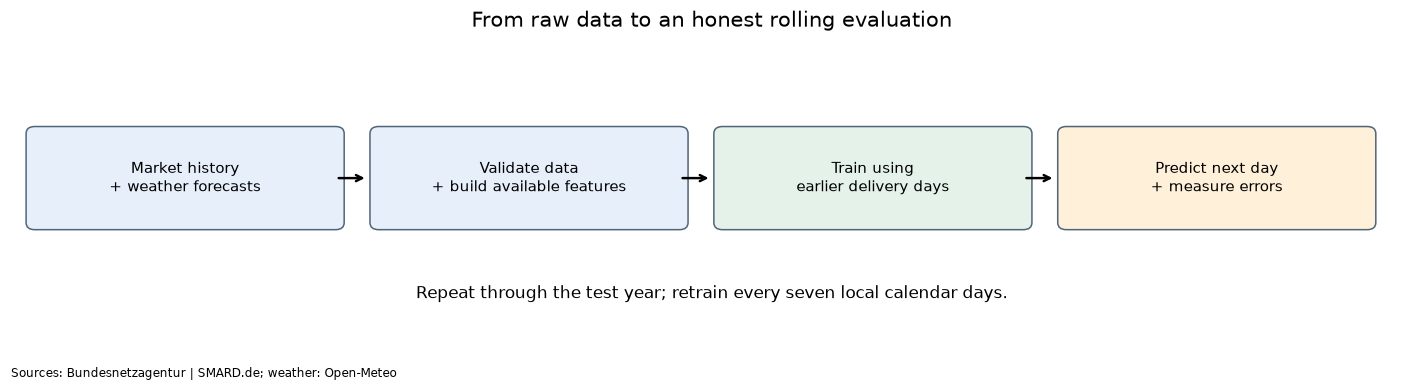

In [2]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set(xlim=(0, 13), ylim=(0, 3.5))
ax.axis('off')
boxes = [
    (0.2, 1.4, 'Market history\n+ weather forecasts', '#e7f0fa'),
    (3.4, 1.4, 'Validate data\n+ build available features', '#e7f0fa'),
    (6.6, 1.4, 'Train using\nearlier delivery days', '#e4f2e9'),
    (9.8, 1.4, 'Predict next day\n+ measure errors', '#fff0d9'),
]
for x, y, label, color in boxes:
    ax.add_patch(FancyBboxPatch((x, y), 2.8, 1.0, boxstyle='round,pad=0.08',
                               facecolor=color, edgecolor='#516579'))
    ax.text(x + 1.4, y + .5, label, ha='center', va='center', fontsize=10)
for x in [3.1, 6.3, 9.5]:
    ax.annotate('', xy=(x+.2, 1.9), xytext=(x-.1, 1.9), arrowprops={'arrowstyle': '->', 'lw': 1.6})
ax.text(6.5, .55, 'Repeat through the test year; retrain every seven local calendar days.',
        ha='center', fontsize=11)
ax.set_title('From raw data to an honest rolling evaluation', fontsize=14)
finish(fig, '00_workflow')

## 1. Load the data and preserve its identity

While both market snapshots exist, use `smard_sample.parquet` (the later download already
used in this notebook). After you replace the older `smard.parquet` with that file, the
fallback below uses `smard.parquet`. Never concatenate these overlapping snapshots.
SHA-256 hashes record exactly which bytes produced the results.

In [3]:
raw = ROOT / 'data/raw'
market_path = raw / 'smard_sample.parquet'
if not market_path.exists():
    market_path = raw / 'smard.parquet'
paths = {'market': market_path, 'weather_archive': raw / 'weather_archive.parquet',
         'weather_forecast': raw / 'weather_forecast.parquet'}
datasets = {name: pd.read_parquet(path) for name, path in paths.items()}
market, archive, forecast = (datasets[k] for k in ['market', 'weather_archive', 'weather_forecast'])
forecast_meta = json.loads((raw / 'weather_forecast.metadata.json').read_text(encoding='utf-8'))
manifest = {name: {'file': str(path.relative_to(ROOT)),
                   'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
            for name, path in paths.items()}
display(pd.DataFrame(manifest).T)
display(market.head())
print('Forecast source:', forecast_meta['endpoint'])
print('Weather model:', forecast_meta['model'], '| lead time:', forecast_meta['lead_hours'], 'hours')
assert forecast_meta['source'] == 'forecast' and forecast_meta['lead_hours'] == 48
assert forecast_meta['endpoint'] == 'https://previous-runs-api.open-meteo.com/v1/forecast'

,file,sha256
market,data\raw\smard_sample.parquet,3b43a706a14dbca277f3f9d01d1d66a1fcf0fde5af5f66...
weather_archive,data\raw\weather_archive.parquet,4a87e5e029a403a9351c612a2f9025bb3e5f1f166fbe90...
weather_forecast,data\raw\weather_forecast.parquet,22c8ed65cec69e0aa9d1e58f3818dc1e05c3e310f1e958...


,price_eur_mwh,load_mwh,residual_load_mwh,solar_mwh,wind_onshore_mwh,wind_offshore_mwh
ts,,,,,,
2019-01-01 00:00:00+00:00,10.07,41631.25,16465.75,0.0,22297.25,2868.25
2019-01-01 01:00:00+00:00,-4.08,40085.00,14456.25,0.0,23168.50,2460.25
2019-01-01 02:00:00+00:00,-9.91,39269.75,12101.50,0.0,24471.75,2696.50
2019-01-01 03:00:00+00:00,-7.41,39032.75,10134.25,0.0,26320.50,2578.00
2019-01-01 04:00:00+00:00,-12.55,38570.50,8295.25,0.0,27898.00,2377.25


Forecast source: https://previous-runs-api.open-meteo.com/v1/forecast
Weather model: ecmwf_ifs025 | lead time: 48 hours


## 2. Units, columns and a worked negative-price example

One row is one UTC hour. `ts`/`time` is the delivery/valid timestamp, not the publication
timestamp. Calendar features use Europe/Berlin. Prices cover the DE-LU bidding zone;
the physical market series cover DE.

**MWh is energy:** 1 MWh = 1,000 kWh. 50,000 MWh in a one-hour interval corresponds
to 50,000 MW average power. **EUR/MWh is a price:** EUR 100/MWh = EUR 0.10/kWh
before retail charges. Actual generation is output, not installed generating capacity.

Negative wholesale prices can occur when offered supply is abundant relative to demand
and some generators accept negative bids because stopping/restarting is costly or other
operating incentives apply. The physical system still balances. A buyer purchasing 10 MWh
at -80.01 EUR/MWh has an energy-only payment of -800.10 EUR: it receives EUR 800.10.
The seller pays that amount under this simple spot transaction. Contracts, fees and retail
tariffs can change what individual participants ultimately pay.

Keep negative prices and spikes: they are part of the forecasting problem.
[SMARD explanation](https://www.smard.de/page/en/topic-article/5892/15618/negative-electricity-prices).

In [4]:
example_time = pd.Timestamp('2024-06-15 12:00', tz='UTC')
example = market.loc[example_time]
definitions = {
    TARGET: ('EUR/MWh', 'Wholesale day-ahead price; the prediction target.'),
    'load_mwh': ('MWh', 'Actual grid load; system consumption with provider accounting boundaries.'),
    'residual_load_mwh': ('MWh', 'Grid load minus solar, onshore wind and offshore wind.'),
    'solar_mwh': ('MWh', 'Electricity produced by photovoltaic installations during the interval.'),
    'wind_onshore_mwh': ('MWh', 'Electricity produced by wind turbines on land.'),
    'wind_offshore_mwh': ('MWh', 'Electricity produced by offshore wind turbines.'),
}
market_dictionary = pd.DataFrame([
    {'column': c, 'unit': unit, 'meaning': meaning, 'example_value': example[c]}
    for c, (unit, meaning) in definitions.items()
]).set_index('column')
display(market_dictionary)
print('Example UTC:', example_time, '| local:', example_time.tz_convert(TZ))
computed_residual = (example.load_mwh - example.solar_mwh
                     - example.wind_onshore_mwh - example.wind_offshore_mwh)
print(f'Residual = {example.load_mwh:,.2f} - {example.solar_mwh:,.2f}'
      f' - {example.wind_onshore_mwh:,.2f} - {example.wind_offshore_mwh:,.2f}'
      f' = {computed_residual:,.2f} MWh')
print(f'Energy-only payment for buying 10 MWh: EUR {10 * example[TARGET]:,.2f}')
market_dictionary.to_csv(OUT / 'market_dictionary.csv')

,unit,meaning,example_value
column,,,
price_eur_mwh,EUR/MWh,Wholesale day-ahead price; the prediction target.,-80.01
load_mwh,MWh,Actual grid load; system consumption with prov...,46043.50
residual_load_mwh,MWh,"Grid load minus solar, onshore wind and offsho...",478.75
solar_mwh,MWh,Electricity produced by photovoltaic installat...,31521.25
wind_onshore_mwh,MWh,Electricity produced by wind turbines on land.,12282.25
wind_offshore_mwh,MWh,Electricity produced by offshore wind turbines.,1761.25


Example UTC: 2024-06-15 12:00:00+00:00 | local: 2024-06-15 14:00:00+02:00
Residual = 46,043.50 - 31,521.25 - 12,282.25 - 1,761.25 = 478.75 MWh
Energy-only payment for buying 10 MWh: EUR -800.10


Each weather name is `location__variable`: five locations times four variables = 20 columns.
`temperature_2m` is degrees Celsius; `wind_speed_100m` is km/h (divide by 3.6 for m/s);
`shortwave_radiation` is W/m2; `cloud_cover` is percent. The weather points are regional
proxies, not region-wide averages. Radiation is the API's preceding-hour mean, retained
at the provider timestamp here; it is not claimed to represent the exact same physical
interval as the market energy measurement.

Archive weather is retrospective model-based information, not perfect ground truth.
It is used only for descriptive analysis below. Forecast weather is a separate archive
of model predictions at a 48-hour lead. No archive values enter either price model.
[Open-Meteo definitions](https://open-meteo.com/en/docs/historical-weather-api).

In [5]:
weather_definitions = {
    'temperature_2m': ('degC', 'Air temperature 2 m above ground; may affect heating/cooling demand.'),
    'wind_speed_100m': ('km/h', 'Wind 100 m above ground; proxy for wind-turbine conditions.'),
    'shortwave_radiation': ('W/m2', 'Incoming horizontal solar radiation; proxy for available sunlight.'),
    'cloud_cover': ('%', 'Sky cloud fraction; 100 means fully cloud-covered, not zero radiation.'),
}
weather_dictionary = []
for column in archive:
    location, variable = column.split('__')
    unit, meaning = weather_definitions[variable]
    weather_dictionary.append({'column': column, 'location': location, 'unit': unit,
                               'meaning': meaning, 'archive_example': archive.loc[example_time, column],
                               'forecast_example_48h': forecast.loc[example_time, column]})
weather_dictionary = pd.DataFrame(weather_dictionary).set_index('column')
display(weather_dictionary)
weather_dictionary.to_csv(OUT / 'weather_dictionary.csv')

,location,unit,meaning,archive_example,forecast_example_48h
column,,,,,
north_sea_coast__temperature_2m,north_sea_coast,degC,Air temperature 2 m above ground; may affect h...,15.5,17.0
north_sea_coast__wind_speed_100m,north_sea_coast,km/h,Wind 100 m above ground; proxy for wind-turbin...,45.9,36.5
north_sea_coast__shortwave_radiation,north_sea_coast,W/m2,Incoming horizontal solar radiation; proxy for...,586.0,677.0
north_sea_coast__cloud_cover,north_sea_coast,%,Sky cloud fraction; 100 means fully cloud-cove...,45.0,23.0
brandenburg__temperature_2m,brandenburg,degC,Air temperature 2 m above ground; may affect h...,21.4,19.3
brandenburg__wind_speed_100m,brandenburg,km/h,Wind 100 m above ground; proxy for wind-turbin...,32.1,28.4
brandenburg__shortwave_radiation,brandenburg,W/m2,Incoming horizontal solar radiation; proxy for...,823.0,418.0
brandenburg__cloud_cover,brandenburg,%,Sky cloud fraction; 100 means fully cloud-cove...,46.0,0.0
ruhr__temperature_2m,ruhr,degC,Air temperature 2 m above ground; may affect h...,17.6,17.9


## 3. Data-quality audit (all downloaded rows)

Separate a missing timestamp from a present timestamp with a missing value. Missing
recent generation is retained as missing, never converted to zero. UTC has no DST gap;
local delivery-day lengths must be compared to the calendar's expected 23/24/25 hours.
The first/last partial day can also contain fewer than 24 observations.

In [6]:
quality_rows, missing_rows = [], []
for name, df in datasets.items():
    assert isinstance(df.index, pd.DatetimeIndex) and str(df.index.tz) == 'UTC'
    expected = pd.date_range(df.index.min(), df.index.max(), freq='h')
    quality_rows.append({'dataset': name, 'rows': len(df), 'columns': df.shape[1],
                         'start_utc': df.index.min(), 'end_utc': df.index.max(),
                         'duplicates': int(df.index.duplicated().sum()),
                         'sorted': df.index.is_monotonic_increasing,
                         'missing_timestamps': len(expected.difference(df.index)),
                         'non_finite_non_null': int((~np.isfinite(df) & df.notna()).sum().sum())})
    for column in df:
        mask = df[column].isna()
        missing_rows.append({'dataset': name, 'column': column, 'missing': int(mask.sum()),
                             'missing_pct': float(mask.mean() * 100),
                             'first_missing': df.index[mask].min(), 'last_missing': df.index[mask].max()})
quality = pd.DataFrame(quality_rows).set_index('dataset')
missing_values = pd.DataFrame(missing_rows)
display(quality)
display(missing_values.loc[missing_values.missing > 0])
assert (quality.duplicates == 0).all() and quality['sorted'].all()
assert (quality.missing_timestamps == 0).all() and (quality.non_finite_non_null == 0).all()
quality.to_csv(OUT / 'data_quality.csv')
missing_values.to_csv(OUT / 'missing_values.csv', index=False)
display(market.describe(percentiles=[.01, .5, .99]).T)

,rows,columns,start_utc,end_utc,duplicates,sorted,missing_timestamps,non_finite_non_null
dataset,,,,,,,,
market,67822,6,2019-01-01 00:00:00+00:00,2026-09-26 21:00:00+00:00,0,True,0,0
weather_archive,67800,20,2019-01-01 00:00:00+00:00,2026-09-25 23:00:00+00:00,0,True,0,0
weather_forecast,21792,20,2024-04-01 00:00:00+00:00,2026-09-25 23:00:00+00:00,0,True,0,0


,dataset,column,missing,missing_pct,first_missing,last_missing
1,market,load_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
2,market,residual_load_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
3,market,solar_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
4,market,wind_onshore_mwh,28,0.041285,2026-09-25 18:00:00+00:00,2026-09-26 21:00:00+00:00
5,market,wind_offshore_mwh,27,0.039810,2026-09-25 19:00:00+00:00,2026-09-26 21:00:00+00:00
29,weather_forecast,north_sea_coast__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
33,weather_forecast,brandenburg__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
37,weather_forecast,ruhr__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
41,weather_forecast,bavaria__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00
45,weather_forecast,baden_wuerttemberg__cloud_cover,129,0.591960,2026-04-17 15:00:00+00:00,2026-04-22 23:00:00+00:00


,count,mean,std,min,1%,50%,99%,max
price_eur_mwh,67822.0,95.917205,91.561801,-500.00,-11.1000,78.675,472.4697,936.28
load_mwh,67794.0,54570.284995,9629.554123,30902.75,36018.1975,54447.570,74490.8500,81319.50
residual_load_mwh,67794.0,33025.534944,14097.555440,-15561.59,-1285.5475,33885.640,63177.8200,74638.75
solar_mwh,67794.0,6735.517077,10555.029630,0.00,0.0000,238.500,42128.5195,58055.53
wind_onshore_mwh,67794.0,11923.932304,9410.937843,46.50,655.3709,9246.000,39226.4700,48499.50
wind_offshore_mwh,67795.0,2885.281240,1963.406757,0.00,34.2500,2658.500,6984.6924,8448.34


In [7]:
local_index = market.index.tz_convert(TZ)
day_counts = market.groupby(local_index.normalize()).size().rename('observed_hours').to_frame()
day_counts['expected_hours'] = [len(pd.date_range(day, day + pd.DateOffset(days=1),
                                                freq='h', inclusive='left')) for day in day_counts.index]
day_counts['complete'] = day_counts.observed_hours == day_counts.expected_hours
display(day_counts.loc[(day_counts.expected_hours != 24) | ~day_counts.complete])
day_counts.to_csv(OUT / 'delivery_day_coverage.csv')

physical = ['load_mwh', 'solar_mwh', 'wind_onshore_mwh', 'wind_offshore_mwh']
print('Negative physical energy values:', (market[physical] < 0).sum().to_dict())
print('Negative residual-load hours (valid):', int((market.residual_load_mwh < 0).sum()))
for df_name, df in [('archive', archive), ('forecast', forecast)]:
    invalid = {}
    for c in df:
        if c.endswith('cloud_cover'):
            invalid[c] = int(((df[c] < 0) | (df[c] > 100)).sum())
        elif c.endswith(('wind_speed_100m', 'shortwave_radiation')):
            invalid[c] = int((df[c] < 0).sum())
    print(df_name, 'weather range violations:', sum(invalid.values()))

,observed_hours,expected_hours,complete
ts,,,
2019-01-01 00:00:00+01:00,23,24,False
2019-03-31 00:00:00+01:00,23,23,True
2019-10-27 00:00:00+02:00,25,25,True
2020-03-29 00:00:00+01:00,23,23,True
2020-10-25 00:00:00+02:00,25,25,True
2021-03-28 00:00:00+01:00,23,23,True
2021-10-31 00:00:00+02:00,25,25,True
2022-03-27 00:00:00+01:00,23,23,True
2022-10-30 00:00:00+02:00,25,25,True


Negative physical energy values: {'load_mwh': 0, 'solar_mwh': 0, 'wind_onshore_mwh': 0, 'wind_offshore_mwh': 0}
Negative residual-load hours (valid): 872
archive weather range violations: 0
forecast weather range violations: 0


In [8]:
residual_recomputed = (market.load_mwh - market.solar_mwh
                       - market.wind_onshore_mwh - market.wind_offshore_mwh)
residual_error = (market.residual_load_mwh - residual_recomputed).rename('residual_difference_mwh')
residual_flags = market.loc[residual_error.abs() > .1].copy()
residual_flags['residual_difference_mwh'] = residual_error
display(residual_error.describe())
display(residual_flags.loc[residual_flags.residual_difference_mwh.abs().nlargest(10).index])
print('Differences greater than 0.1 MWh:', len(residual_flags))
residual_flags.to_csv(OUT / 'residual_load_flags.csv')

snapshot_differences = []
if (raw / 'smard.parquet').exists() and (raw / 'smard_sample.parquet').exists():
    older = pd.read_parquet(raw / 'smard.parquet')
    newer = pd.read_parquet(raw / 'smard_sample.parquet')
    common = older.index.intersection(newer.index)
    for c in market:
        a, b = older.loc[common, c], newer.loc[common, c]
        different = a.ne(b) & ~(a.isna() & b.isna())
        snapshot_differences.append({'column': c, 'different_cells': int(different.sum()),
                                     'max_abs_difference_when_both_present': (a-b).abs().max()})
    display(pd.DataFrame(snapshot_differences))
else:
    print('Only one market snapshot remains; no overlapping files were combined.')

count    67794.000000
mean        -0.003573
std          0.414381
min       -103.410000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.880000
Name: residual_difference_mwh, dtype: float64

,price_eur_mwh,load_mwh,residual_load_mwh,solar_mwh,wind_onshore_mwh,wind_offshore_mwh,residual_difference_mwh
ts,,,,,,,
2026-09-23 04:00:00+00:00,300.00,54672.14,52196.17,1.52,1597.94,773.10,-103.41
2021-01-06 16:00:00+00:00,61.84,67835.00,60243.25,1.00,4394.75,3179.50,-16.50
2021-01-06 14:00:00+00:00,57.53,64927.00,57386.38,353.50,4191.50,3009.50,13.88
2021-01-06 07:00:00+00:00,53.41,63076.25,52245.50,98.75,5993.25,4747.75,9.00
2021-01-05 12:00:00+00:00,63.82,70739.00,54252.00,1128.25,9128.25,6226.50,-4.00
2021-01-05 17:00:00+00:00,61.61,71259.75,55054.25,1.00,10132.75,6067.75,-4.00
2021-01-04 20:00:00+00:00,45.64,62577.00,47027.00,1.00,9604.75,5940.75,-3.50
2021-01-04 10:00:00+00:00,60.00,70311.25,53185.75,1049.00,10290.00,5783.25,-3.25
2021-01-04 14:00:00+00:00,59.46,69013.00,52313.75,214.50,10721.00,5760.50,-3.25


Differences greater than 0.1 MWh: 71


,column,different_cells,max_abs_difference_when_both_present
0,price_eur_mwh,0,0.0
1,load_mwh,20,4.0
2,residual_load_mwh,20,4.0
3,solar_mwh,0,0.0
4,wind_onshore_mwh,0,0.0
5,wind_offshore_mwh,1,0.0


**Quality decisions:** retain negative prices, negative residual load and all price spikes;
retain missing recent physical values; keep published residual load and export discrepancies
for investigation; never fill gaps using future values. Use timestamp joins rather than row
position. Source revisions and missing publication timestamps limit an exact historical
information reconstruction. Data completeness alone does not prove absence of leakage.

## 4. Explore development data before the test period

All relationship and distribution plots in this section stop before the frozen test period.
The same-hour physical variables and archive weather help explain the market, but they
are **not** available as same-hour actuals for a day-ahead forecast. Correlation is not
causation. Pooling years can hide changes in fuel prices, installed renewable capacity,
outages and cross-border trading, none of which is fully represented in these six columns.

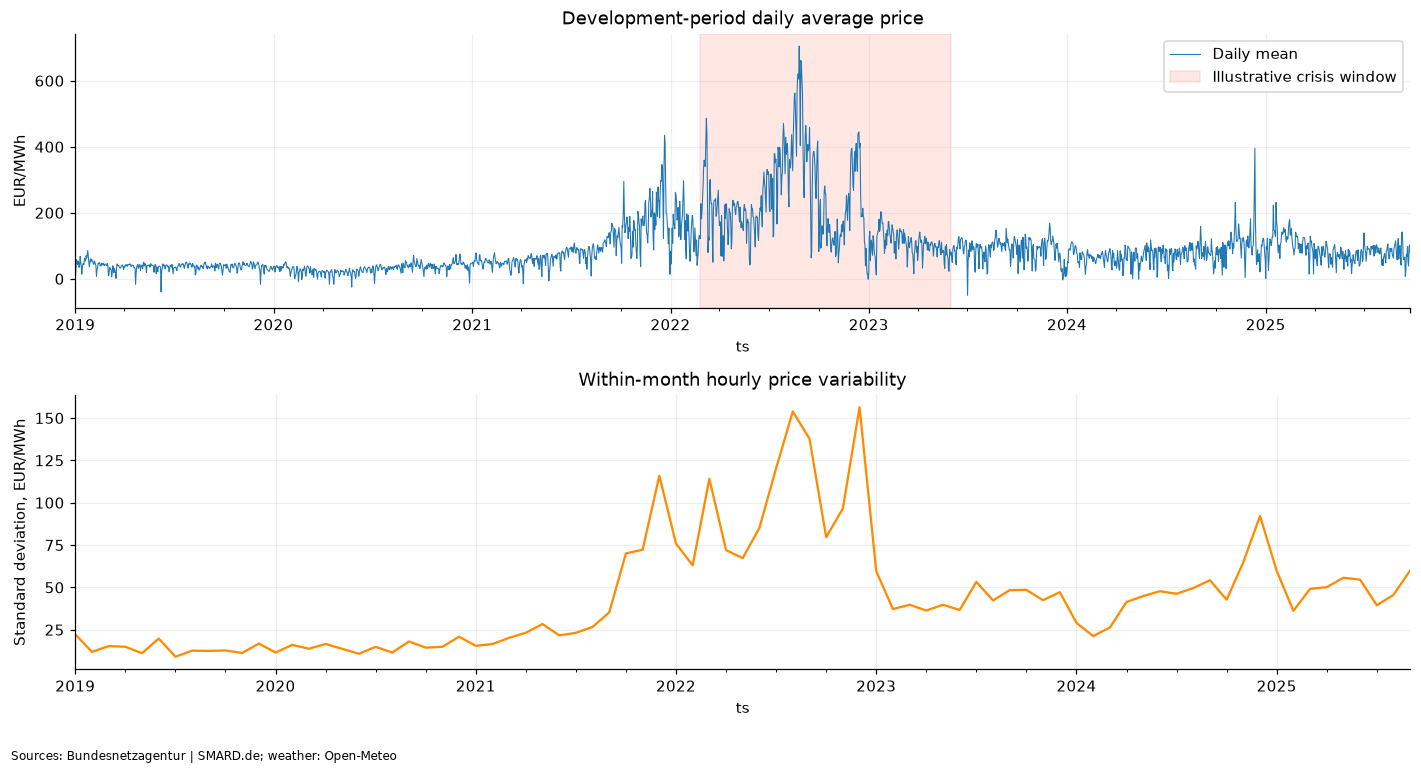

In [9]:
eda = market.loc[market.index < TEST_BEGIN].copy()
eda_local = eda.tz_convert(TZ)
price = eda[TARGET]
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
price.resample('D').mean().plot(ax=axes[0], linewidth=.7, label='Daily mean')
axes[0].set(title='Development-period daily average price', ylabel='EUR/MWh')
axes[0].axvspan(pd.Timestamp('2022-02-24', tz='UTC'), pd.Timestamp('2023-06-01', tz='UTC'),
               color='tomato', alpha=.15, label='Illustrative crisis window')
axes[0].legend()
price.resample('MS').std().plot(ax=axes[1], color='darkorange')
axes[1].set(title='Within-month hourly price variability', ylabel='Standard deviation, EUR/MWh')
finish(fig, '01_price_history')

Central plot omits 1298 out-of-range hours; original data unchanged.


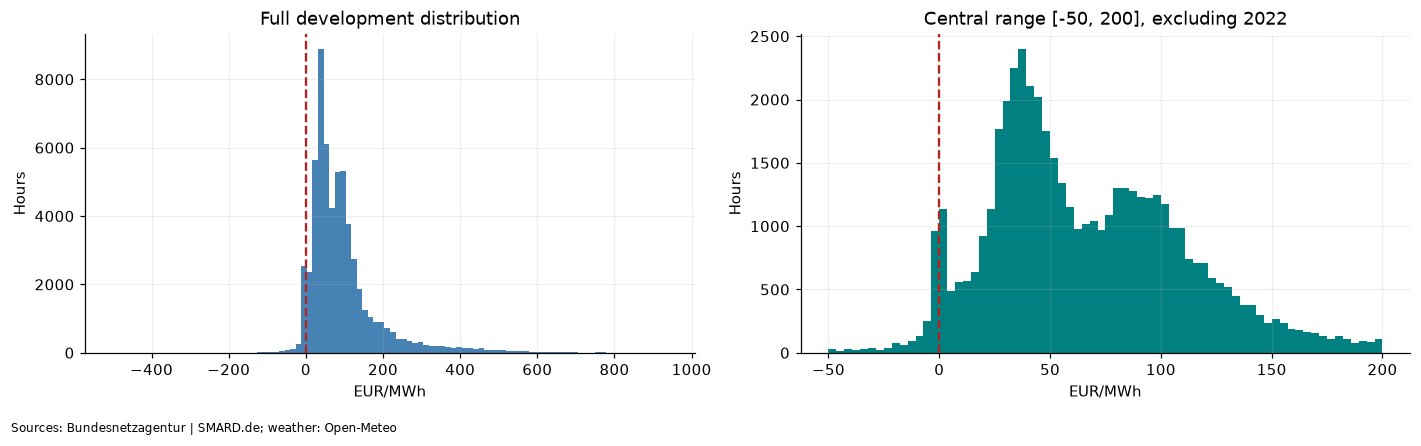

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(price, bins=100, color='steelblue')
axes[0].set(title='Full development distribution', xlabel='EUR/MWh', ylabel='Hours')
without_2022 = price.loc[price.index.tz_convert(TZ).year != 2022]
central = without_2022.loc[without_2022.between(-50, 200)]
axes[1].hist(central, bins=70, color='teal')
axes[1].set(title='Central range [-50, 200], excluding 2022', xlabel='EUR/MWh', ylabel='Hours')
for ax in axes:
    ax.axvline(0, color='firebrick', linestyle='--')
print('Central plot omits', len(without_2022)-len(central), 'out-of-range hours; original data unchanged.')
finish(fig, '02_price_distribution')

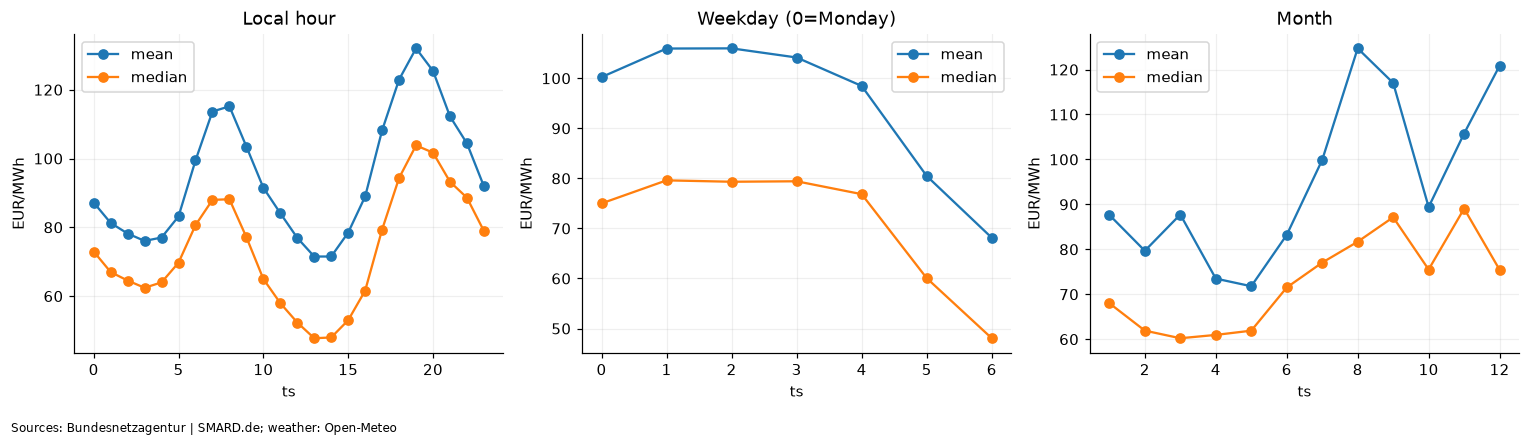

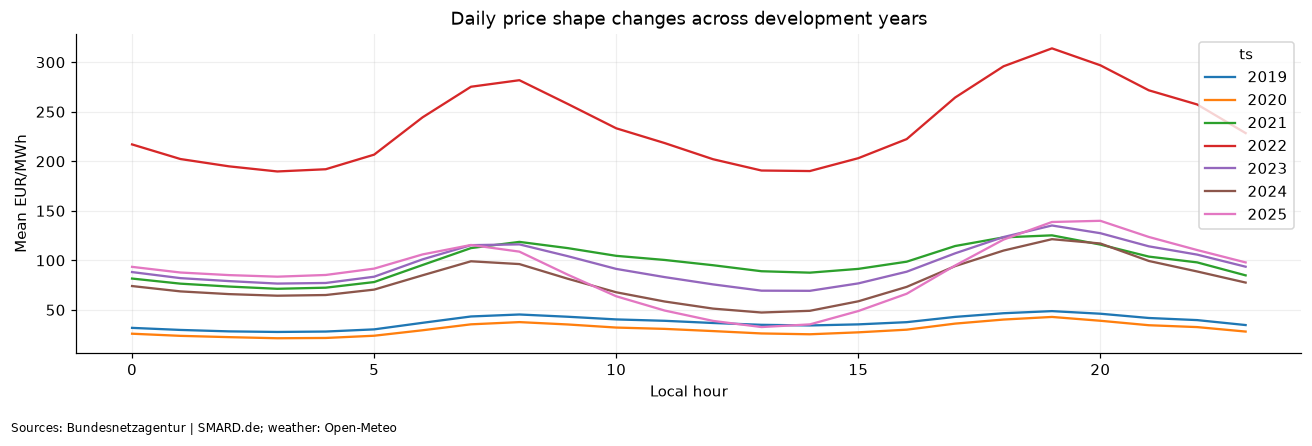

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for key, ax, title in [(eda_local.index.hour, axes[0], 'Local hour'),
                       (eda_local.index.dayofweek, axes[1], 'Weekday (0=Monday)'),
                       (eda_local.index.month, axes[2], 'Month')]:
    grouped = eda_local.groupby(key)[TARGET].agg(['mean', 'median'])
    grouped.plot(ax=ax, marker='o', title=title)
    ax.set_ylabel('EUR/MWh')
finish(fig, '03_calendar_patterns')
hour_year = eda_local.pivot_table(values=TARGET, index=eda_local.index.hour,
                                 columns=eda_local.index.year, aggfunc='mean')
fig, ax = plt.subplots(figsize=(12, 4))
hour_year.plot(ax=ax, title='Daily price shape changes across development years')
ax.set(xlabel='Local hour', ylabel='Mean EUR/MWh')
finish(fig, '04_hour_by_year')

,hours,mean,median,minimum,maximum,negative_hours,negative_pct,coverage_note
ts,,,,,,,,
2019,8759,37.67,38.06,-90.01,121.46,211,2.41,partial first local year
2020,8784,30.47,30.99,-83.94,200.04,298,3.39,full local year
2021,8760,96.85,75.48,-69.00,620.00,139,1.59,full local year
2022,8760,235.45,208.34,-19.04,871.00,69,0.79,full local year
2023,8760,95.18,98.02,-500.00,524.27,301,3.44,full local year
2024,8784,78.51,79.59,-135.45,936.28,457,5.20,full local year
2025,6407,87.67,94.17,-250.32,583.40,525,8.19,partial year before holdout


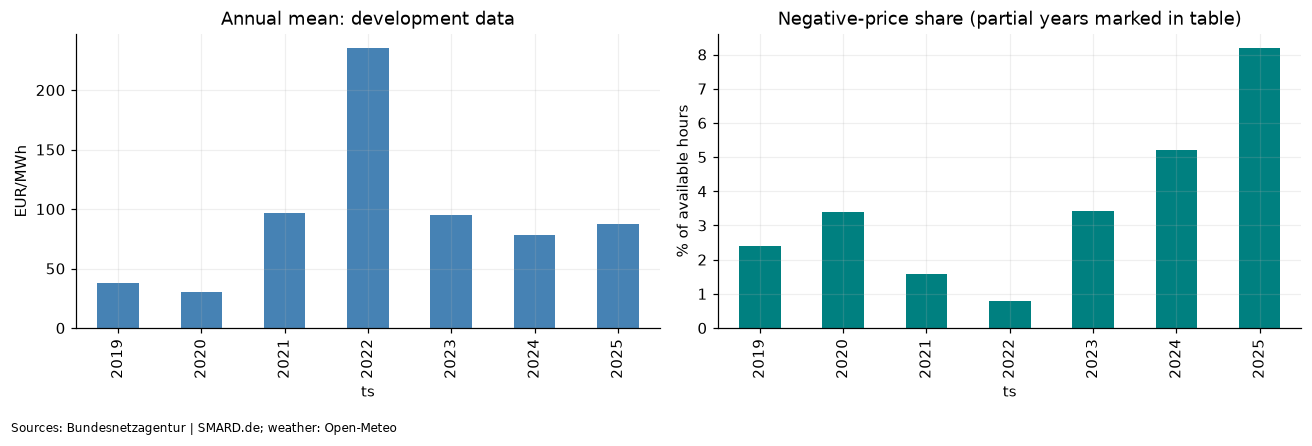

In [12]:
annual = eda_local.groupby(eda_local.index.year)[TARGET].agg(hours='size', mean='mean', median='median', minimum='min', maximum='max')
annual['negative_hours'] = eda_local[TARGET].lt(0).groupby(eda_local.index.year).sum()
annual['negative_pct'] = 100 * annual.negative_hours / annual.hours
annual['coverage_note'] = ['partial first local year' if y == 2019 else
                           'partial year before holdout' if y == 2025 else 'full local year'
                           for y in annual.index]
display(annual.round(2))
annual.to_csv(OUT / 'development_annual_prices.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
annual['mean'].plot.bar(ax=axes[0], color='steelblue', title='Annual mean: development data')
annual.negative_pct.plot.bar(ax=axes[1], color='teal', title='Negative-price share (partial years marked in table)')
axes[0].set_ylabel('EUR/MWh')
axes[1].set_ylabel('% of available hours')
finish(fig, '05_annual_regimes')

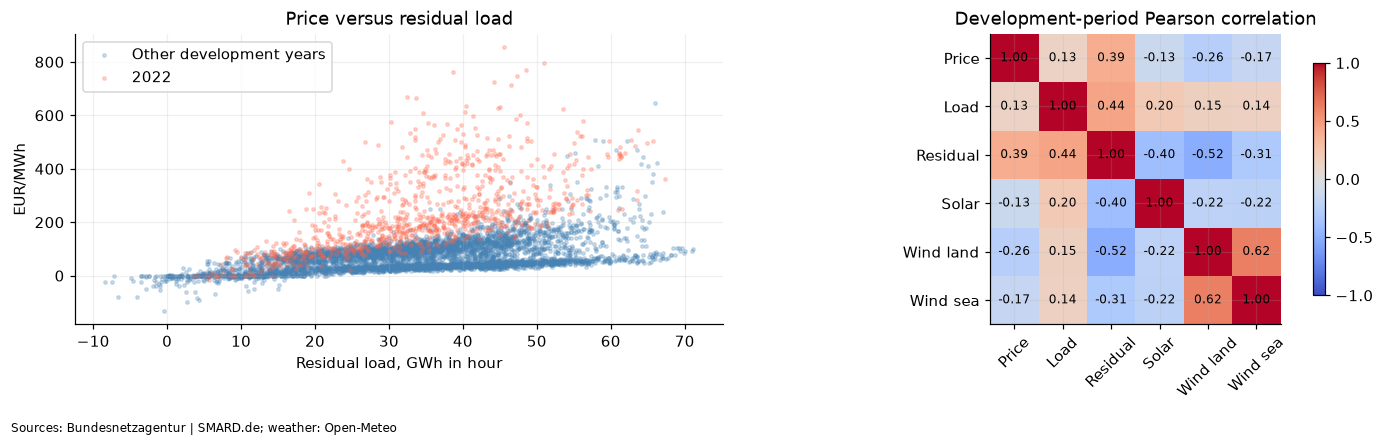

price_eur_mwh        1.000000
residual_load_mwh    0.393464
load_mwh             0.131249
solar_mwh           -0.132724
wind_offshore_mwh   -0.168069
wind_onshore_mwh    -0.261692
Name: correlation_with_price, dtype: float64

In [13]:
sample = eda.dropna().sample(min(6000, len(eda.dropna())), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for is_crisis, label, color in [(False, 'Other development years', 'steelblue'), (True, '2022', 'tomato')]:
    part = sample.loc[(sample.index.tz_convert(TZ).year == 2022) == is_crisis]
    axes[0].scatter(part.residual_load_mwh / 1000, part[TARGET], s=5, alpha=.25, label=label, color=color)
axes[0].set(xlabel='Residual load, GWh in hour', ylabel='EUR/MWh', title='Price versus residual load')
axes[0].legend()
corr = eda.corr()
im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
labels = ['Price', 'Load', 'Residual', 'Solar', 'Wind land', 'Wind sea']
axes[1].set(xticks=range(6), yticks=range(6), xticklabels=labels, yticklabels=labels,
            title='Development-period Pearson correlation')
axes[1].tick_params(axis='x', rotation=45)
for i in range(6):
    for j in range(6):
        axes[1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[1], shrink=.8)
finish(fig, '06_market_relationships')
display(corr[TARGET].sort_values(ascending=False).rename('correlation_with_price'))

Weather can affect price through expected generation and demand. More sunlight often supports
more PV output; stronger wind often supports more wind generation; temperature affects demand.
These relationships are not exact conversion formulas: installed capacity, plant behaviour,
geography and time of year also matter. Residual load itself is mostly a derived column.

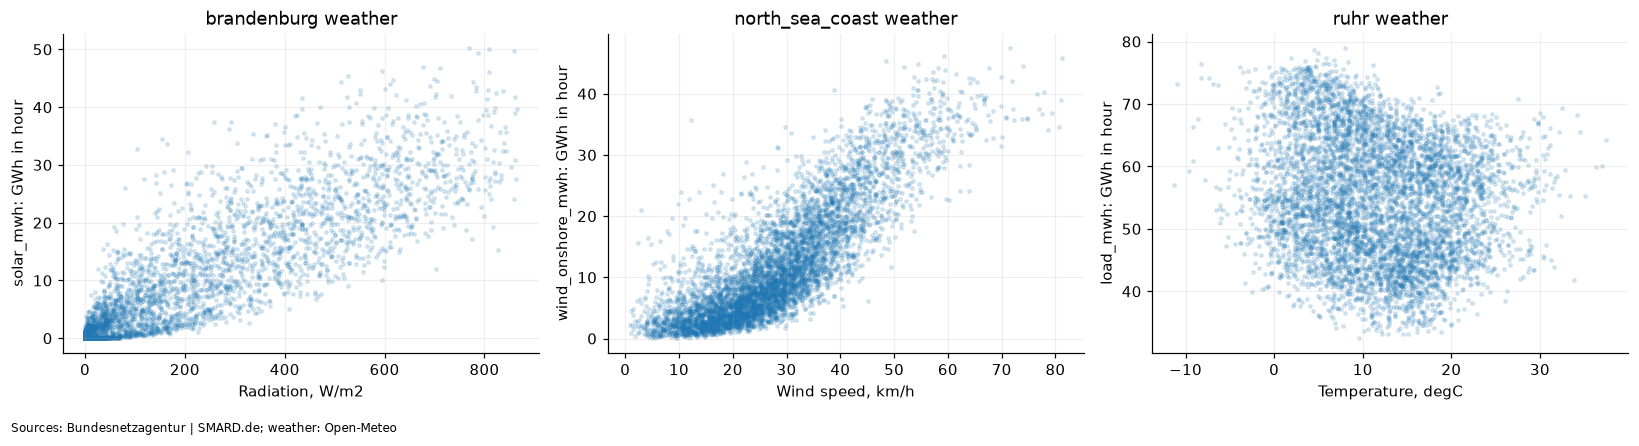

,price_eur_mwh,solar_mwh,wind_onshore_mwh,load_mwh
north_sea_coast__temperature_2m,-0.011,0.404,-0.228,-0.215
north_sea_coast__wind_speed_100m,-0.233,-0.183,0.832,0.134
north_sea_coast__shortwave_radiation,-0.107,0.858,-0.226,0.195
north_sea_coast__cloud_cover,-0.003,-0.117,0.164,0.099
brandenburg__temperature_2m,-0.034,0.459,-0.238,-0.183
brandenburg__wind_speed_100m,-0.220,-0.231,0.809,0.096
brandenburg__shortwave_radiation,-0.121,0.901,-0.217,0.215
brandenburg__cloud_cover,0.011,-0.096,0.159,0.133
ruhr__temperature_2m,-0.016,0.465,-0.228,-0.180
ruhr__wind_speed_100m,-0.234,-0.230,0.801,0.106


In [14]:
weather_eda = eda.join(archive, how='inner')
weather_sample = weather_eda.dropna().sample(min(6000, len(weather_eda.dropna())), random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('brandenburg__shortwave_radiation', 'solar_mwh', 'Radiation, W/m2'),
         ('north_sea_coast__wind_speed_100m', 'wind_onshore_mwh', 'Wind speed, km/h'),
         ('ruhr__temperature_2m', 'load_mwh', 'Temperature, degC')]
for ax, (x, y, label) in zip(axes, pairs):
    ax.scatter(weather_sample[x], weather_sample[y] / 1000, s=5, alpha=.15)
    ax.set(xlabel=label, ylabel=f'{y}: GWh in hour', title=f'{x.split("__")[0]} weather')
finish(fig, '07_weather_relationships')
weather_correlations = weather_eda.corr().loc[archive.columns, [TARGET, 'solar_mwh', 'wind_onshore_mwh', 'load_mwh']]
display(weather_correlations.round(3))
weather_correlations.to_csv(OUT / 'development_weather_correlations.csv')

## 5. Forecast provenance and availability

Open-Meteo is free for non-commercial use within published rate limits; local LightGBM
training incurs no API/model fee. Commercial API access requires the appropriate paid plan.
[Pricing](https://open-meteo.com/en/pricing).

The downloader now uses ECMWF IFS 0.25-degree forecasts from the **Previous Runs API**, with
`*_previous_day2` fields (48-hour lead), rather than the stitched historical endpoint.
This deliberately uses older forecasts. Exact publication times are not supplied, so the
availability claim assumes publication lag is shorter than the buffer printed below. It
is not a reconstruction of the most recent D-1 forecast run. [API semantics](https://open-meteo.com/en/docs/previous-runs-api).

Coverage begins in April 2024 in this experiment. Do not fabricate forecast history by filling
earlier dates with archive weather. Radiation is kept as a preceding-hour weather predictor.

In [15]:
local_days = forecast.index.tz_convert(TZ).normalize()
issue_local = (local_days.tz_localize(None) - pd.Timedelta(days=1) + pd.Timedelta(hours=11)).tz_localize(TZ)
nominal_forecast_time = forecast.index - pd.Timedelta(hours=forecast_meta['lead_hours'])
buffer_hours = (issue_local.tz_convert('UTC') - nominal_forecast_time).total_seconds() / 3600
print('Minimum nominal forecast-age buffer before 11:00 D-1:', buffer_hours.min(), 'hours')
assert buffer_hours.min() > 0
display(pd.DataFrame({'valid_time_utc': forecast.index[:3],
                      'nominal_forecast_time_utc': nominal_forecast_time[:3],
                      'prediction_issue_local': issue_local[:3]}))
print('Missing forecast cells:', int(forecast.isna().sum().sum()))

Minimum nominal forecast-age buffer before 11:00 D-1: 11.0 hours


,valid_time_utc,nominal_forecast_time_utc,prediction_issue_local
0,2024-04-01 00:00:00+00:00,2024-03-30 00:00:00+00:00,2024-03-31 11:00:00+02:00
1,2024-04-01 01:00:00+00:00,2024-03-30 01:00:00+00:00,2024-03-31 11:00:00+02:00
2,2024-04-01 02:00:00+00:00,2024-03-30 02:00:00+00:00,2024-03-31 11:00:00+02:00


Missing forecast cells: 645


## 6. Feature engineering: the full implementation

The raw target price for a delivery hour is the answer we want to predict. We therefore
never pass that column directly to the model. Instead, we construct information available
before the prediction deadline.

**Calendar features** describe local hour, weekday, month, weekends and national holidays.
The sine/cosine pairs put adjacent times near each other on a circle: 23:00 and 00:00 are
neighbours. State-specific holiday calendars are not included in this initial model.

In [16]:
def calendar_features(index):
    local = index.tz_convert(TZ)
    de_holidays = holidays.Germany(years=range(local.year.min(), local.year.max() + 1))
    f = pd.DataFrame(index=index)
    f['hour'] = local.hour
    f['dow'] = local.dayofweek
    f['month'] = local.month
    f['is_weekend'] = (local.dayofweek >= 5).astype(int)
    f['is_holiday'] = pd.Index(local.date).isin(list(de_holidays)).astype(int)
    f['hour_sin'] = np.sin(2 * np.pi * f['hour'] / 24)
    f['hour_cos'] = np.cos(2 * np.pi * f['hour'] / 24)
    f['doy_sin'] = np.sin(2 * np.pi * local.dayofyear / 365.25)
    f['doy_cos'] = np.cos(2 * np.pi * local.dayofyear / 365.25)
    return f

**Lag features** look backward by a fixed number of elapsed hours: 48, 72, 168 and 336.
For example, `price_eur_mwh_lag168h` is last week's price at the same UTC hour.
Across a DST change this can differ from the same local clock hour.

**Rolling features** summarize the price level and variability. We shift prices by 48
hours *before* computing the windows. The 24-hour rolling mean at t therefore uses
t−71 through t−48, and cannot include t itself. We keep the conservative 48-hour rule
for this reproduction; exact availability can differ by variable.

In [17]:
def lag_features(df, cols):
    f = pd.DataFrame(index=df.index)
    for c in cols:
        for lag in SAFE_LAGS_H:
            f[f'{c}_lag{lag}h'] = df[c].shift(lag)
    past = df[TARGET].shift(48)
    f['price_roll24_mean'] = past.rolling(24).mean()
    f['price_roll24_std'] = past.rolling(24).std()
    f['price_roll168_mean'] = past.rolling(168).mean()
    return f

**Assembling the table:** create a regular hourly index, build the calendar and lag inputs,
align forecast weather by timestamp, then attach the target as a separate training label.
The first 14 days have incomplete features because of the longest lag. No missing value
is replaced with a value from the future.

In [18]:
def build_features(market, weather_forecast=None):
    """Return a feature matrix aligned to `market.index` (hourly, UTC)."""
    market = market.asfreq('h')
    lag_cols = [c for c in market.columns if c in {TARGET, 'load_mwh', 'residual_load_mwh', 'solar_mwh', 'wind_onshore_mwh', 'wind_offshore_mwh'}]
    parts = [calendar_features(market.index), lag_features(market, lag_cols)]
    if weather_forecast is not None:
        parts.append(weather_forecast.reindex(market.index))
    X = pd.concat(parts, axis=1)
    X[TARGET] = market[TARGET]
    return X

### Construct the feature tables and freeze the comparison

`build_features` creates 9 calendar predictors, 24 lagged market predictors and 3 rolling
price statistics: 36 inputs, or 56 with forecast weather. Lags are 48, 72, 168 and 336 elapsed
hours. They can differ from the same local clock hour across DST. All rolling statistics
end 48 hours before delivery. The first 14 days are unavailable because of lag warm-up.

The returned table also contains the target. The backtester excludes it from X.
Both learned models use the **same eligible training timestamps**, starting when forecast
coverage exists. This isolates the effect of adding weather more fairly. Weekly retraining
uses calendar days; each fit uses only earlier delivery days, up to a two-year window.
Earlier test-day outcomes may enter later weekly fits once known: this is rolling evaluation.

Forecast cloud cover has source gaps. LightGBM handles these NaNs natively; we retain
them without filling from observations or future data. All other weather fields and
market predictors must be present. The backtest's explicit missing-feature option is
enabled only for LightGBM.

Baselines require only their price lag. All four methods must predict every expected test
hour; a missing prediction causes a clear failure rather than a silently smaller test set.

In [19]:
X_market = build_features(market)
X_weather = build_features(market, weather_forecast=forecast)
assert len(X_market.columns) - 1 == 36
assert len(X_weather.columns) - 1 == 56
required = list(X_market.columns) + [c for c in forecast if not c.endswith('cloud_cover')]
eligible = X_weather.dropna(subset=required).index
learn_market = X_market.loc[eligible]
learn_weather = X_weather.loc[eligible]
print('Eligible learned-model data:', eligible.min(), 'to', eligible.max(), '| rows:', len(eligible))
missing_test = expected_test.difference(eligible)
assert len(missing_test) == 0, f'Missing eligible test hours: {list(missing_test[:10])}'
assert market.loc[expected_test, TARGET].notna().all()

split_info = pd.DataFrame([
    {'role': 'Initial training (fixed parameters; no tuning)', 'start': eligible.min(),
     'end': eligible[eligible < TEST_BEGIN].max(), 'hours': int((eligible < TEST_BEGIN).sum())},
    {'role': 'Rolling retrospective test', 'start': TEST_BEGIN,
     'end': expected_test[-1], 'hours': len(expected_test)},
])
display(split_info)
print('Latest raw generation may be absent while older lagged features remain available.')

Eligible learned-model data: 2024-04-01 00:00:00+00:00 to 2026-09-25 23:00:00+00:00 | rows: 21792


,role,start,end,hours
0,Initial training (fixed parameters; no tuning),2024-04-01 00:00:00+00:00,2025-09-24 21:00:00+00:00,13006
1,Rolling retrospective test,2025-09-24 22:00:00+00:00,2026-09-24 21:00:00+00:00,8760


Latest raw generation may be absent while older lagged features remain available.


### One delivery hour, its inputs and its target

The table below exposes the available inputs for one concrete training example. The
target is shown separately to prevent confusing it with a predictor. Both learned models
use the same training timestamps, beginning when the weather forecasts are available.

ts,value,role
hour,14.00,calendar feature
dow,5.00,calendar feature
month,6.00,calendar feature
is_weekend,1.00,calendar feature
is_holiday,0.00,calendar feature
...,...,...
baden_wuerttemberg__temperature_2m,19.20,forecast weather
baden_wuerttemberg__wind_speed_100m,27.20,forecast weather
baden_wuerttemberg__shortwave_radiation,832.00,forecast weather
baden_wuerttemberg__cloud_cover,0.00,forecast weather


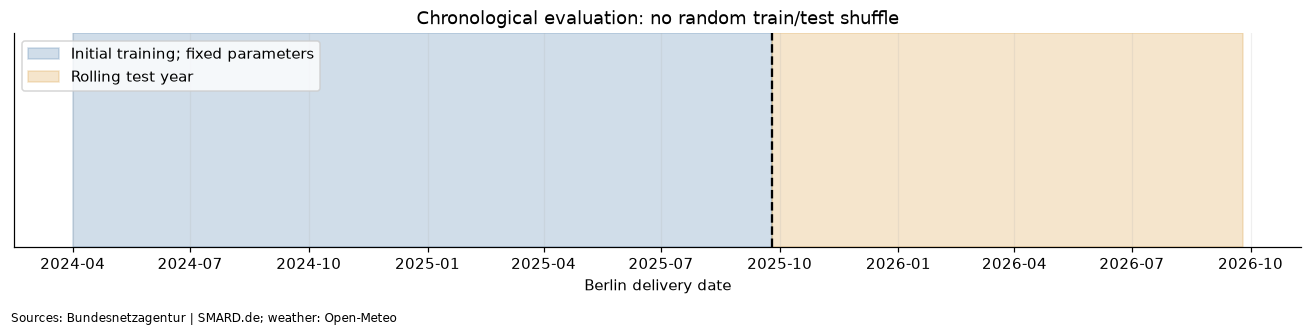

In [20]:
feature_example = X_weather.loc[[example_time]].T.rename(columns={example_time: 'value'})
feature_example['role'] = ['target (never an input)' if c == TARGET else
                           'forecast weather' if '__' in c else
                           'historical market feature' if ('lag' in c or 'roll' in c) else
                           'calendar feature' for c in feature_example.index]
display(feature_example)

fig, ax = plt.subplots(figsize=(12, 3))
start = eligible.min().tz_convert(TZ)
cutoff = TEST_BEGIN.tz_convert(TZ)
stop = TEST_STOP.tz_convert(TZ)
ax.axvspan(start, cutoff, color='#4478a9', alpha=.25, label='Initial training; fixed parameters')
ax.axvspan(cutoff, stop, color='#d99b35', alpha=.25, label='Rolling test year')
ax.axvline(cutoff, color='black', linestyle='--')
ax.set(ylim=(0, 1), yticks=[], title='Chronological evaluation: no random train/test shuffle', xlabel='Berlin delivery date')
ax.legend(loc='upper left')
finish(fig, '11_evaluation_timeline')

## 7. Testing design: the full rolling backtest

A random split would let the model learn from dates later than the date it is supposed
to predict. Instead, for delivery day D:

1. If it is a retraining day, select only delivery dates before D, within a two-year window.
2. Fit a fresh model using those rows. Both learned models use identical eligible dates.
3. Predict all available hours of D with the fitted model.
4. Store actual and predicted prices, and move to the next delivery day.

Retraining occurs every seven **calendar days**, including across DST. Outcomes from earlier
test days can enter subsequent fits after becoming known; that is the intended rolling protocol.

MAE = mean(|actual − predicted|). RMSE = square root of mean((actual − predicted)²).
We do not divide by the actual price, so zero and negative prices cause no percentage-error problem.
Missing-feature support is explicit and enabled only for LightGBM, which can handle NaNs.

In [21]:
@dataclass
class BacktestResult:
    predictions: pd.DataFrame

    def metrics(self):
        e = self.predictions['y_true'] - self.predictions['y_pred']
        return {'MAE': float(e.abs().mean()), 'RMSE': float(np.sqrt((e ** 2).mean())), 'n_hours': len(e)}

def rolling_backtest(data, make_model, test_start, test_end, train_window_days=365 * 2, retrain_every_days=7, allow_missing_features=False):
    """For each delivery day D in [test_start, test_end], train on data strictly before D
    (retraining every `retrain_every_days`) and predict all hours of D.

    Set `allow_missing_features` only for models that natively support NaNs.
    Missing targets are always excluded; callers should assert expected coverage.
    """
    data = data.dropna(subset=[TARGET])
    local_day = data.index.tz_convert(TZ).normalize()
    days = pd.date_range(test_start, test_end, freq='D', tz=TZ)
    feature_cols = [c for c in data.columns if c != TARGET]
    model, last_fit, out = (None, None, [])
    for day in days:
        if model is None or (day.date() - last_fit.date()).days >= retrain_every_days:
            train = data[(local_day < day) & (local_day >= day - pd.DateOffset(days=train_window_days))]
            if not allow_missing_features:
                train = train.dropna()
            model = make_model().fit(train[feature_cols], train[TARGET])
            last_fit = day
        test = data[local_day == day]
        if not allow_missing_features:
            test = test.dropna(subset=feature_cols)
        if test.empty:
            continue
        out.append(pd.DataFrame({'y_true': test[TARGET], 'y_pred': model.predict(test[feature_cols])}, index=test.index))
    if not out:
        raise ValueError('No evaluable hours in the requested test period')
    return BacktestResult(pd.concat(out))

### The two baseline models

Both baselines implement `fit` and `predict`, so the same evaluator can call every model.
Their `fit` method has nothing to learn: they simply return an already available price lag.
A learned model must provide useful improvement over these inexpensive rules.

In [22]:
class SeasonalNaive:
    """Baseline: price at the same hour one week earlier (feature price_eur_mwh_lag168h)."""

    def fit(self, X, y):
        return self

    def predict(self, X):
        return X[f'{TARGET}_lag168h'].to_numpy()

### Run the baseline evaluation

**Weekly seasonal naive:** predict the price from 168 hours earlier.
**Two-day naive:** predict the price from 48 hours earlier.

MAE is the average absolute error in EUR/MWh. RMSE gives more weight to large errors.
Neither uses a percentage denominator, so zero and negative prices are valid.
The results are measurements from this run, not expected performance targets.

In [23]:
class Lag48Baseline:
    def fit(self, X, y):
        return self
    def predict(self, X):
        return X[f'{TARGET}_lag48h'].to_numpy()

results = {}
def evaluate(name, data, factory, allow_missing_features=False):
    started = time.perf_counter()
    result = rolling_backtest(data, factory, TEST_START, TEST_END,
                              train_window_days=730, retrain_every_days=7,
                              allow_missing_features=allow_missing_features)
    pd.testing.assert_index_equal(result.predictions.index.as_unit('ns'), expected_test.as_unit('ns'), check_names=False)
    assert np.isfinite(result.predictions.to_numpy()).all(), f'Non-finite predictions from {name}'
    results[name] = result
    print(name, result.metrics(), f'elapsed {time.perf_counter()-started:.1f}s')
    return result

evaluate('Seasonal naive (168h)', X_market[[TARGET, f'{TARGET}_lag168h']], SeasonalNaive)
evaluate('Two-day naive (48h)', X_market[[TARGET, f'{TARGET}_lag48h']], Lag48Baseline)
baseline_results = pd.DataFrame({name: result.metrics() for name, result in results.items()}).T
display(baseline_results.round(3))
baseline_results.to_csv(OUT / 'baseline_results.csv', index_label='model')

Seasonal naive (168h) {'MAE': 36.73968721461188, 'RMSE': 56.568971189498896, 'n_hours': 8760} elapsed 0.9s


Two-day naive (48h) {'MAE': 37.866756849315074, 'RMSE': 58.1701532140231, 'n_hours': 8760} elapsed 1.0s


,MAE,RMSE,n_hours
Seasonal naive (168h),36.740,56.569,8760.0
Two-day naive (48h),37.867,58.170,8760.0


## 8. Enhanced models: LightGBM without and with weather

LightGBM combines decision trees to learn nonlinear relationships between the available
inputs and price. These fixed initial parameters have not been tuned on the test period.
Absolute-error training aligns with MAE. Both models use identical dates and settings;
only the extra 20 forecast-weather inputs differ. Adding inputs is not a guarantee of
improvement: the measured results below decide that.

**How to read the configuration:** 250 trees are added sequentially; a learning rate of
0.05 limits each update; at most 31 leaves per tree and at least 40 observations per leaf
control complexity. L2 regularization discourages overly complex fits. Absolute-error
training aligns the objective with MAE. A fixed seed and two CPU threads make the run
reproducible and keep laptop resource use modest. These settings reproduce the original
experiment; no test-score-driven parameter search is performed here.

In [24]:
model_params = dict(n_estimators=250, learning_rate=.05, num_leaves=31,
                    min_child_samples=40, reg_lambda=1.0, objective='regression_l1',
                    random_state=SEED, n_jobs=2, verbosity=-1)
def make_lgbm():
    return LGBMRegressor(**model_params)

In [25]:
evaluate('LightGBM market', learn_market, make_lgbm, allow_missing_features=True);

LightGBM market {'MAE': 29.96198168031522, 'RMSE': 44.82662321759161, 'n_hours': 8760} elapsed 44.7s


The second model adds the 20 forecast-weather inputs. It sees no retrospective archive
weather. When cloud forecasts are missing, LightGBM handles the missing values directly;
the corresponding test hours remain in the evaluation.

In [26]:
evaluate('LightGBM market + forecast weather', learn_weather, make_lgbm, allow_missing_features=True);

LightGBM market + forecast weather {'MAE': 19.192585961299894, 'RMSE': 32.07089335656704, 'n_hours': 8760} elapsed 67.1s


,MAE,RMSE,n_hours,MAE_improvement_vs_weekly_pct
Seasonal naive (168h),36.740,56.569,8760,0.000
Two-day naive (48h),37.867,58.170,8760,-3.068
LightGBM market,29.962,44.827,8760,18.448
LightGBM market + forecast weather,19.193,32.071,8760,47.761


Adding forecast weather changes MAE by **+35.94% improvement** relative to the market-only model (negative means worse). All methods score the same **8,760 hours**.

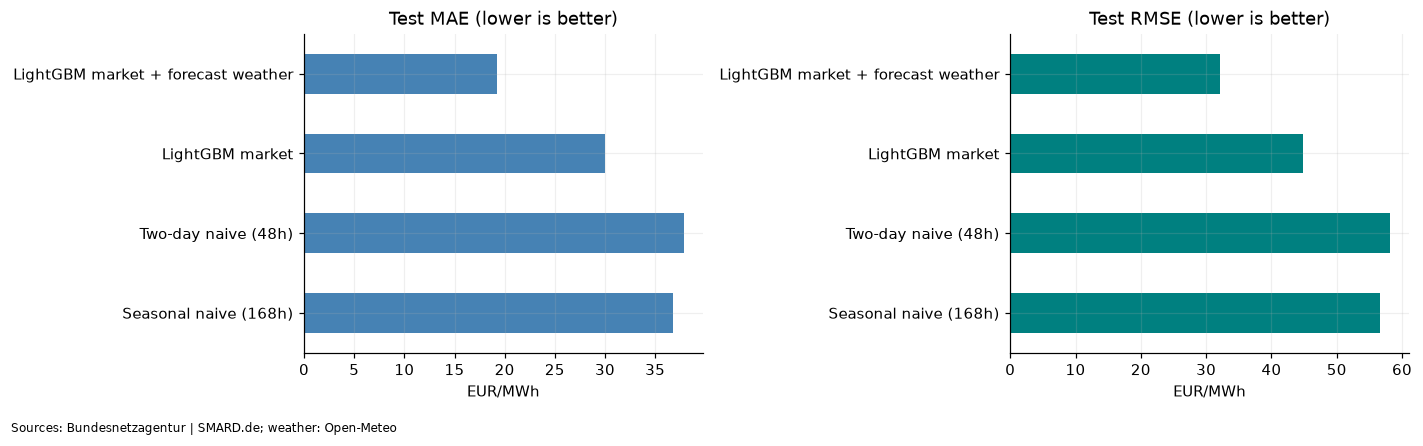

In [27]:
scores = pd.DataFrame({name: result.metrics() for name, result in results.items()}).T
scores['n_hours'] = scores.n_hours.astype(int)
scores['MAE_improvement_vs_weekly_pct'] = 100 * (1 - scores.MAE / scores.loc['Seasonal naive (168h)', 'MAE'])
display(scores.round(3))
scores.to_csv(OUT / 'model_results.csv', index_label='model')
predictions = pd.DataFrame({'actual': market.loc[expected_test, TARGET]}, index=expected_test)
for name, result in results.items():
    predictions[name] = result.predictions.y_pred
predictions.to_parquet(OUT / 'test_predictions.parquet')
predictions.to_csv(OUT / 'test_predictions.csv', index_label='timestamp_utc')
weather_gain = 100 * (1 - scores.loc['LightGBM market + forecast weather', 'MAE'] / scores.loc['LightGBM market', 'MAE'])
display(Markdown(f'Adding forecast weather changes MAE by **{weather_gain:+.2f}% improvement** relative to the market-only model (negative means worse). All methods score the same **{len(expected_test):,} hours**.'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scores.MAE.plot.barh(ax=axes[0], color='steelblue', title='Test MAE (lower is better)')
scores.RMSE.plot.barh(ax=axes[1], color='teal', title='Test RMSE (lower is better)')
for ax in axes:
    ax.set_xlabel('EUR/MWh')
finish(fig, '08_model_comparison')

## 9. Where do the errors occur?

Report error by hour, weekend and negative-price regime. These slices diagnose failure;
they are not permission to tune on the holdout. The example week is fixed to the first
seven test days rather than selected for a favourable visual result.

,Seasonal naive (168h),Two-day naive (48h),LightGBM market,LightGBM market + forecast weather
weekday,37.94,37.69,31.19,20.41
weekend,33.73,38.31,26.88,16.15


,Seasonal naive (168h),Two-day naive (48h),LightGBM market,LightGBM market + forecast weather
negative price,55.05,66.47,44.86,25.63
nonnegative price,35.62,36.12,29.05,18.80


Regime hour counts: {'nonnegative price': 8257, 'negative price': 503}


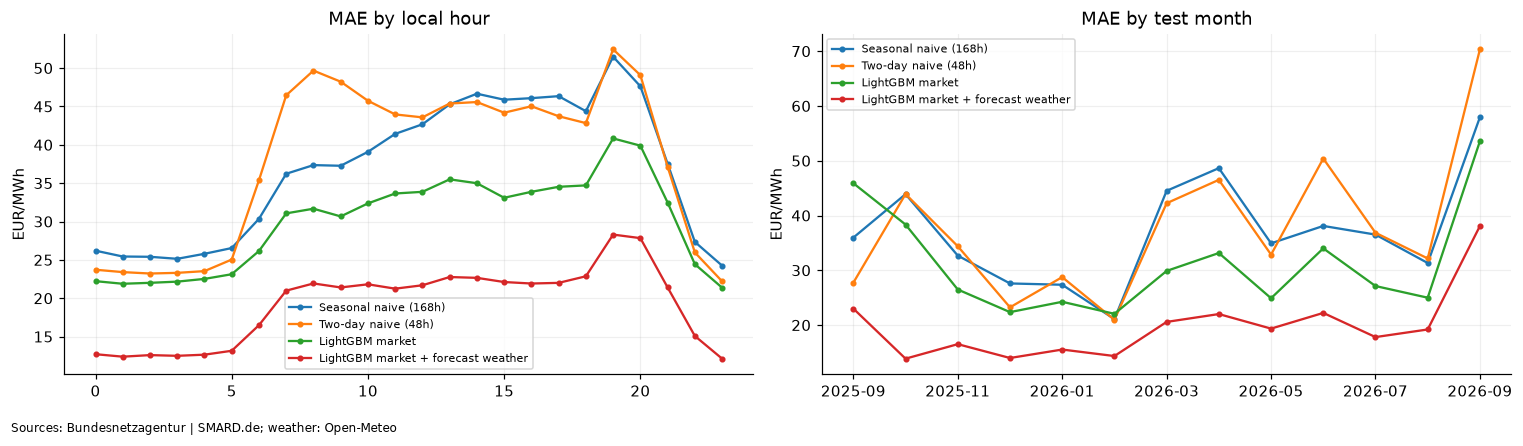

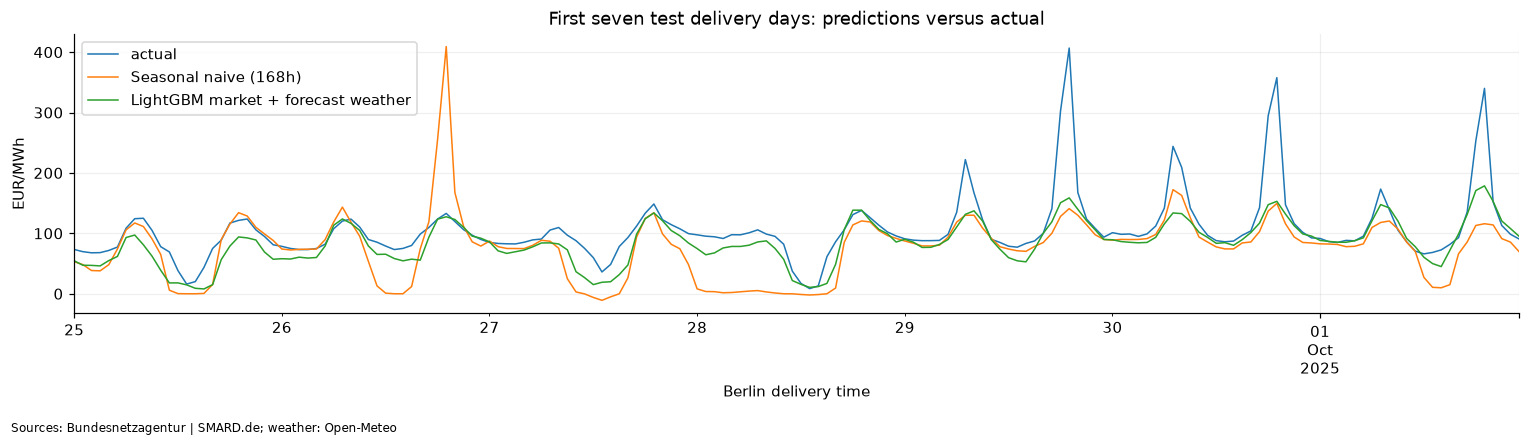

In [28]:
errors = predictions.drop(columns='actual').sub(predictions.actual, axis=0).abs()
test_local = predictions.index.tz_convert(TZ)
hourly_mae = errors.groupby(test_local.hour).mean()
weekend_mae = errors.groupby(np.where(test_local.dayofweek >= 5, 'weekend', 'weekday')).mean()
regime_mae = errors.groupby(np.where(predictions.actual < 0, 'negative price', 'nonnegative price')).mean()
monthly_mae = errors.groupby(test_local.strftime('%Y-%m')).mean()
display(weekend_mae.round(2))
display(regime_mae.round(2))
print('Regime hour counts:', pd.Series(np.where(predictions.actual < 0, 'negative price', 'nonnegative price')).value_counts().to_dict())
hourly_mae.to_csv(OUT / 'mae_by_local_hour.csv')
weekend_mae.to_csv(OUT / 'mae_by_weekend.csv')
regime_mae.to_csv(OUT / 'mae_by_price_regime.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_mae.plot(ax=axes[0], marker='.', title='MAE by local hour')
monthly_mae.plot(ax=axes[1], marker='.', title='MAE by test month')
for ax in axes:
    ax.set_ylabel('EUR/MWh')
    ax.legend(fontsize=7)
finish(fig, '09_error_slices')

week_stop = (pd.Timestamp(TEST_START, tz=TZ) + pd.DateOffset(days=7)).tz_convert('UTC')
example_week = predictions.loc[predictions.index < week_stop].tz_convert(TZ)
fig, ax = plt.subplots(figsize=(14, 4))
example_week[['actual', 'Seasonal naive (168h)', 'LightGBM market + forecast weather']].plot(ax=ax, linewidth=1)
ax.set(title='First seven test delivery days: predictions versus actual', ylabel='EUR/MWh', xlabel='Berlin delivery time')
finish(fig, '10_forecast_week')

### Further diagnostic: bias and extreme-price errors

A low average error can conceal systematic underprediction of expensive hours.
The diagonal in the scatter plot represents perfect predictions. A point below it is
an underprediction; a point above it is an overprediction. The histogram shows signed
error (prediction − actual): values to the left of zero are underpredictions.

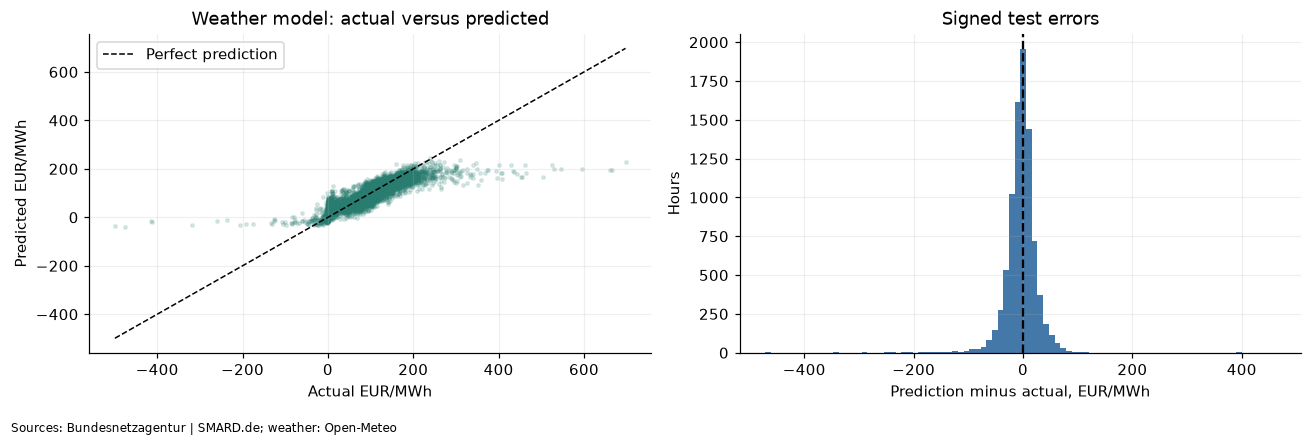

Mean signed error: -3.20 EUR/MWh
95th percentile absolute error: 53.88 EUR/MWh


In [29]:
weather_name = 'LightGBM market + forecast weather'
signed_error = predictions[weather_name] - predictions.actual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(predictions.actual, predictions[weather_name], s=5, alpha=.15, color='#287d70')
limits = [min(predictions.actual.min(), predictions[weather_name].min()),
          max(predictions.actual.max(), predictions[weather_name].max())]
axes[0].plot(limits, limits, color='black', linestyle='--', linewidth=1, label='Perfect prediction')
axes[0].set(xlabel='Actual EUR/MWh', ylabel='Predicted EUR/MWh', title='Weather model: actual versus predicted')
axes[0].legend()
axes[1].hist(signed_error, bins=90, color='#4478a9')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set(xlabel='Prediction minus actual, EUR/MWh', ylabel='Hours', title='Signed test errors')
finish(fig, '12_prediction_diagnostics')
print(f'Mean signed error: {signed_error.mean():+.2f} EUR/MWh')
print(f'95th percentile absolute error: {signed_error.abs().quantile(.95):.2f} EUR/MWh')

## 10. Validation checks for this notebook

The following checks exercise the functions defined **above**, without importing the
project's test suite. They verify feature causality for a changed price, the exact 48-hour
lag, retraining across the spring DST transition, preservation of missing-feature rows,
complete test-hour coverage, and independent recalculation of the reported metrics.

These checks catch implementation errors. They cannot prove historical publication times
or remove source revisions; those remain explicit data limitations.

In [30]:
checks = []

# 1. Changing a target at t must not affect predictors at t or earlier.
small_market = market.loc['2024-05-01':'2024-06-30'].copy()
shock_time = pd.Timestamp('2024-06-15 12:00', tz='UTC')
original_features = build_features(small_market)
changed = small_market.copy()
changed.loc[shock_time, TARGET] += 10000
changed_features = build_features(changed)
predictor_cols = original_features.columns.drop(TARGET)
pd.testing.assert_frame_equal(original_features.loc[:shock_time, predictor_cols],
                              changed_features.loc[:shock_time, predictor_cols])
checks.append(('No changed-price influence on current/past predictors', 'PASS'))

# 2. Hourly regularization means a 48-row shift is a 48-hour lag.
assert original_features.loc[shock_time, f'{TARGET}_lag48h'] == small_market.loc[shock_time-pd.Timedelta(hours=48), TARGET]
checks.append(('48-hour lag matches the exact historical timestamp', 'PASS'))

# 3. Weekly retraining must use local dates across the spring clock change.
toy_index = pd.date_range('2024-03-01', '2024-04-02', freq='h', tz=TZ).tz_convert('UTC')
toy = pd.DataFrame({TARGET: 1.0, 'cloud': np.nan}, index=toy_index)
fit_last_days = []
class MissingAwareTestModel:
    def fit(self, X, y):
        assert X.cloud.isna().all()
        fit_last_days.append(X.index[-1].tz_convert(TZ).date())
        return self
    def predict(self, X):
        assert X.cloud.isna().all()
        return np.ones(len(X))

toy_result = rolling_backtest(toy, MissingAwareTestModel, '2024-03-25', '2024-04-01',
                              allow_missing_features=True)
assert fit_last_days == [pd.Timestamp('2024-03-24').date(), pd.Timestamp('2024-03-31').date()]
assert len(toy_result.predictions) == 8 * 24 - 1
checks.append(('Calendar-based retraining and 23-hour DST day', 'PASS'))
assert toy_result.metrics()['MAE'] == 0
checks.append(('Native missing-feature handling preserves all test hours', 'PASS'))

# 4. Recompute each score independently; require the same complete test index.
assert len(predictions) == len(expected_test) == 8760
assert predictions.index.is_unique and np.isfinite(predictions.to_numpy()).all()
for name, result in results.items():
    pd.testing.assert_index_equal(result.predictions.index.as_unit('ns'), expected_test.as_unit('ns'), check_names=False)
    independent_error = predictions.actual - predictions[name]
    assert np.isclose(independent_error.abs().mean(), scores.loc[name, 'MAE'])
    assert np.isclose(np.sqrt(np.mean(independent_error**2)), scores.loc[name, 'RMSE'])
checks.append(('All four models cover the same 8,760 finite predictions', 'PASS'))
checks.append(('MAE and RMSE match independent calculations', 'PASS'))

# 5. The weather metadata and nominal pre-cutoff buffer are checked independently.
assert forecast_meta['lead_hours'] == 48 and buffer_hours.min() > 0
assert not set(archive.columns).intersection(X_market.columns)
checks.append(('Documented forecast lead and no weather in market-only inputs', 'PASS'))

validation = pd.DataFrame(checks, columns=['check', 'result'])
display(validation)
validation.to_csv(OUT / 'validation_checks.csv', index=False)

,check,result
0,No changed-price influence on current/past pre...,PASS
1,48-hour lag matches the exact historical times...,PASS
2,Calendar-based retraining and 23-hour DST day,PASS
3,Native missing-feature handling preserves all ...,PASS
4,"All four models cover the same 8,760 finite pr...",PASS
5,MAE and RMSE match independent calculations,PASS
6,Documented forecast lead and no weather in mar...,PASS


## 11. Findings to present

The following conclusions are generated from this run's outputs. Improvement is always
measured on identical hours; it is not inferred from a favourable example week.

In [31]:
weekly_mae = scores.loc['Seasonal naive (168h)', 'MAE']
market_mae = scores.loc['LightGBM market', 'MAE']
weather_mae = scores.loc[weather_name, 'MAE']
weather_rmse = scores.loc[weather_name, 'RMSE']
display(Markdown(f"""
**Main result:** adding forecast weather reduces MAE from **{market_mae:.2f}** to
**{weather_mae:.2f} EUR/MWh** compared with the market-only LightGBM model.
That is **{100*(1-weather_mae/market_mae):.1f}% lower MAE**. Relative to the weekly
baseline ({weekly_mae:.2f} EUR/MWh), the reduction is **{100*(1-weather_mae/weekly_mae):.1f}%**.

**Scope:** all four methods predict **{len(predictions):,} test hours**. The weather model's
RMSE is **{weather_rmse:.2f} EUR/MWh**. The diagnostics show why large price spikes still
deserve attention even when average error improves.

**What the data explains:** residual load is largely grid load minus wind and solar.
Weather contributes information about generation and demand, while lagged prices and
calendar features capture historical patterns. These relationships change across years.

**What this does not establish:** live performance, trading profit or calibrated uncertainty.
Exact historical publication times and market revisions are not reconstructed. The forecast
availability assumption must be kept alongside the reported improvement.
"""))


**Main result:** adding forecast weather reduces MAE from **29.96** to
**19.19 EUR/MWh** compared with the market-only LightGBM model.
That is **35.9% lower MAE**. Relative to the weekly
baseline (36.74 EUR/MWh), the reduction is **47.8%**.

**Scope:** all four methods predict **8,760 test hours**. The weather model's
RMSE is **32.07 EUR/MWh**. The diagnostics show why large price spikes still
deserve attention even when average error improves.

**What the data explains:** residual load is largely grid load minus wind and solar.
Weather contributes information about generation and demand, while lagged prices and
calendar features capture historical patterns. These relationships change across years.

**What this does not establish:** live performance, trading profit or calibrated uncertainty.
Exact historical publication times and market revisions are not reconstructed. The forecast
availability assumption must be kept alongside the reported improvement.


## 12. Boundaries of the original experiment

The preceding sections reproduce the original four models. Their initial parameters were fixed,
and the training windows exclude 2022 entirely. Forecast weather has a 48-hour lead convention,
but historical publication delays and revisions are not reconstructed. Five weather coordinates
are coarse regional proxies for a single DE-LU hourly price, not five regional price targets.

**Continue below for the requested improvements.** The extension runs chronological validation,
parameter search, fit diagnostics, stronger baselines and competitors, daily/weekly comparisons,
quantile models, detailed error analysis and a forward-validation workflow. Improvements are
measured, not assumed. Live performance cannot be established without future observations.


In [32]:
run_metadata = {
    'created_at_utc': pd.Timestamp.now(tz='UTC').isoformat(), 'inputs': manifest,
    'test_start_local': TEST_START, 'test_end_local': TEST_END, 'timezone': TZ,
    'expected_test_hours': len(expected_test), 'model_params': model_params,
    'train_window_days': 730, 'retrain_every_days': 7,
    'weather_metadata': forecast_meta,
    'versions': {p: importlib.metadata.version(p) for p in ['pandas', 'numpy', 'lightgbm', 'scikit-learn']},
    'implementation': 'Self-contained notebook; no project imports',
    'quality_policy': 'Raw files unchanged; negative prices kept; no imputation; strict full test-hour coverage.',
}
(OUT / 'run_metadata.json').write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')
print('Saved results, audit tables, predictions and 13 figures to:', OUT)
display(pd.DataFrame({'artifact': sorted(p.name for p in OUT.iterdir() if p.is_file())}))

Saved results, audit tables, predictions and 13 figures to: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast\data\processed\presentation


,artifact
0,00_workflow.png
1,01_price_history.png
2,02_price_distribution.png
3,03_calendar_patterns.png
4,04_hour_by_year.png
5,05_annual_regimes.png
6,06_market_relationships.png
7,07_weather_relationships.png
8,08_model_comparison.png
9,09_error_slices.png


## 13. Extended validation and model improvement

This extension keeps the modular project untouched. Every model, transform, evaluator and
live helper is defined here. Tables and model artifacts go into `data/processed/presentation/improvements/`; figures are saved in its parent presentation folder.

**The two weather files answer different questions.**

| File | Question answered | Modeling role |
|---|---|---|
| `weather_forecast.parquet` | What did an earlier weather forecast expect for this hour? | Training and test predictors |
| `weather_archive.parquet` | What does retrospective weather analysis estimate happened? | Explanatory analysis only |

Archive weather is model-based retrospective information, not a perfect measurement. Both
files can contain the same timestamp and column names, but different values and availability.
An indexed timestamp is the **valid time**, not the publication time. The saved forecast uses
ECMWF IFS 0.25-degree `_previous_day2` values: the API's 48-hour-lead convention.
For a Wednesday 14:00 delivery, this represents Monday 14:00 nominal lead time; it does not
certify the exact moment the API published the result. Our live collector records retrieval
time to establish what our system actually possessed before its cutoff.

We use all five weather locations to predict one DE-LU price. Wind and sunlight inform
renewable supply; temperature can inform demand. Their influence depends on other inputs,
and predictive relationships alone do not establish causation.

[Previous Runs API](https://open-meteo.com/en/docs/previous-runs-api) ·
[Historical weather](https://open-meteo.com/en/docs/historical-weather-api)

In [33]:
import warnings

import joblib
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_pinball_loss
from sklearn.model_selection import ParameterSampler
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

EXT = OUT / 'improvements'
EXT.mkdir(exist_ok=True)
weather_comparison = pd.DataFrame({
    'historical_forecast': forecast.loc[example_time],
    'retrospective_archive': archive.loc[example_time],
})
weather_comparison['difference'] = weather_comparison.historical_forecast - weather_comparison.retrospective_archive
display(weather_comparison.round(2))
display(pd.DataFrame([
    {'file': name, 'first_valid_time': df.index.min(), 'last_valid_time': df.index.max(),
     'rows': len(df), 'columns': df.shape[1], 'model_input': name == 'weather_forecast'}
    for name, df in [('weather_forecast', forecast), ('weather_archive', archive)]
]))

,historical_forecast,retrospective_archive,difference
north_sea_coast__temperature_2m,17.0,15.5,1.5
north_sea_coast__wind_speed_100m,36.5,45.9,-9.4
north_sea_coast__shortwave_radiation,677.0,586.0,91.0
north_sea_coast__cloud_cover,23.0,45.0,-22.0
brandenburg__temperature_2m,19.3,21.4,-2.1
brandenburg__wind_speed_100m,28.4,32.1,-3.7
brandenburg__shortwave_radiation,418.0,823.0,-405.0
brandenburg__cloud_cover,0.0,46.0,-46.0
ruhr__temperature_2m,17.9,17.6,0.3
ruhr__wind_speed_100m,40.8,43.5,-2.7


,file,first_valid_time,last_valid_time,rows,columns,model_input
0,weather_forecast,2024-04-01 00:00:00+00:00,2026-09-25 23:00:00+00:00,21792,20,True
1,weather_archive,2019-01-01 00:00:00+00:00,2026-09-25 23:00:00+00:00,67800,20,False


## 14. Stronger price features and baselines

The original 56 predictors are retained. We add **one 24-hour price lag**, giving 57
predictors. Today's day-ahead prices are normally published yesterday, so they can be
used when predicting tomorrow. This does **not** justify a 24-hour lag for actual load
or generation: some of those physical intervals have not occurred at forecast time.
Historical price publication is assumed; live mode verifies that today's full profile
was actually received before forecasting. Raw same-hour target prices never enter X.

The seasonal naive method is an established benchmark. The 48-hour baseline is a conservative
project reference, not a mandatory standard. We add a 24-hour baseline and a weekday-aware
rule: use 24 hours for Tuesday–Friday delivery and 168 hours for Monday/Saturday/Sunday.
These rules use **elapsed UTC hours**; DST can shift the matching local hour.
They need no fitted parameters and update whenever their source price changes.

[Seasonal naive forecasting](https://otexts.com/fpp3/simple-methods.html)

In [34]:
def enhanced_features(market_frame, forecast_frame):
    frame = build_features(market_frame, weather_forecast=forecast_frame)
    frame[f'{TARGET}_lag24h'] = market_frame[TARGET].asfreq('h').shift(24)
    return frame

enhanced_all = enhanced_features(market, forecast)
feature_columns = list(enhanced_all.columns.drop(TARGET))
cloud_columns = [c for c in forecast if c.endswith('cloud_cover')]
required_columns = [c for c in enhanced_all if c not in cloud_columns]
enhanced = enhanced_all.dropna(subset=required_columns)
assert len(feature_columns) == 57 and TARGET not in feature_columns
assert expected_test.difference(enhanced.index).empty
development = enhanced.loc[enhanced.index < TEST_BEGIN].copy()

def naive_predictions(frame):
    use_previous_day = frame.index.tz_convert(TZ).dayofweek.isin([1, 2, 3, 4])
    return pd.DataFrame({
        'Weekly naive': frame[f'{TARGET}_lag168h'],
        'Two-day naive': frame[f'{TARGET}_lag48h'],
        'Previous-day naive': frame[f'{TARGET}_lag24h'],
        'Weekday-aware naive': np.where(use_previous_day, frame[f'{TARGET}_lag24h'], frame[f'{TARGET}_lag168h']),
    }, index=frame.index)

feature_inventory = pd.DataFrame({'feature': feature_columns})
feature_inventory['group'] = ['weather forecast' if '__' in c else 'market history' if ('lag' in c or 'roll' in c) else 'calendar' for c in feature_columns]
display(feature_inventory.groupby('group').size().rename('count').to_frame())
feature_inventory.to_csv(EXT / 'feature_inventory.csv', index=False)

,count
group,
calendar,9
market history,28
weather forecast,20


## 15. Chronological cross-validation and recorded training errors

Four non-overlapping 28-day validation windows sample different seasons **before**
25 September 2025. Each fold retrains using only prior delivery days and simulates daily
forecasts with weekly refits. Earlier validation outcomes may enter later refits only once
known, exactly as in operation. These are rolling-origin folds, not shuffled K-fold.

Every fit records training MAE/RMSE and its following out-of-sample errors. A large gap
is a warning, not proof of overfitting: drift, rare events and omitted drivers also matter.
Small training errors alone are not evidence of a useful forecast. All imputation/scaling
for linear and neural models is fitted inside the training window. No random early-stopping
split is used. The MLP has a fixed iteration budget; convergence warnings are reported.

The validation periods are used for selection, so their winning score is optimistic.
The previously viewed test year is a retrospective benchmark; new live observations are
needed for a fresh assessment after these decisions.

[Time-series splits](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

In [35]:
FOLD_STARTS = ['2024-11-01', '2025-02-01', '2025-05-01', '2025-08-01']
folds = []
for number, start in enumerate(FOLD_STARTS, 1):
    begin = pd.Timestamp(start, tz=TZ)
    stop = begin + pd.DateOffset(days=28)
    assert stop <= TEST_BEGIN.tz_convert(TZ)
    folds.append({'fold': number, 'start': begin, 'stop': stop})
display(pd.DataFrame(folds))

def regression_metrics(actual, predicted):
    error = np.asarray(predicted, dtype=float) - np.asarray(actual, dtype=float)
    if not len(error) or not np.isfinite(error).all():
        raise ValueError('Metrics require nonempty, finite, aligned predictions.')
    return {'MAE': float(np.abs(error).mean()), 'RMSE': float(np.sqrt(np.mean(error**2))),
            'bias': float(error.mean()), 'median_AE': float(np.median(np.abs(error))),
            'p95_AE': float(np.quantile(np.abs(error), .95)),
            'within_20_pct': float(100*np.mean(np.abs(error) <= 20)), 'n_hours': len(error)}

def audit_backtest(data, factory, begin, stop, window_days=730, retrain_days=7, columns=None):
    # stop is exclusive. Day-ahead prices for D-1 may be training labels for a D forecast.
    begin, stop = pd.Timestamp(begin).tz_convert(TZ), pd.Timestamp(stop).tz_convert(TZ)
    columns = list(columns if columns is not None else data.columns.drop(TARGET))
    assert TARGET not in columns and begin < stop
    expected = pd.date_range(begin, stop, freq='h', inclusive='left').tz_convert('UTC')
    if not expected.difference(data.index).empty:
        raise ValueError('Missing evaluation hours; do not silently shrink the test set.')
    local_day = data.index.tz_convert(TZ).normalize()
    outputs, fit_rows = [], []
    model, last_fit = None, None
    for day in pd.date_range(begin, stop, freq='D', inclusive='left'):
        if model is None or (day.date() - last_fit.date()).days >= retrain_days:
            train = data.loc[(local_day < day) & (local_day >= day-pd.DateOffset(days=window_days))].dropna(subset=[TARGET])
            if len(train) < 100:
                raise ValueError('Insufficient training observations.')
            assert train.index.max() < day.tz_convert('UTC')
            started = time.perf_counter()
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                model = factory().fit(train[columns], train[TARGET])
            fit_id = len(fit_rows)
            train_scores = regression_metrics(train[TARGET], model.predict(train[columns]))
            fit_rows.append({'fit_id': fit_id, 'fit_day': day, 'train_start': train.index.min(),
                             'train_end': train.index.max(), 'n_train': len(train),
                             'train_MAE': train_scores['MAE'], 'train_RMSE': train_scores['RMSE'],
                             'fit_seconds': time.perf_counter()-started,
                             'warnings': ' | '.join(sorted(set(str(w.message) for w in caught)))})
            last_fit = day
        test = data.loc[local_day == day]
        outputs.append(pd.DataFrame({'actual': test[TARGET], 'prediction': model.predict(test[columns]),
                                     'fit_id': fit_id}, index=test.index))
    pred = pd.concat(outputs)
    pd.testing.assert_index_equal(pred.index.as_unit('ns'), expected.as_unit('ns'), check_names=False)
    assert np.isfinite(pred[['actual', 'prediction']].to_numpy()).all()
    fit_log = pd.DataFrame(fit_rows).set_index('fit_id')
    for fid, group in pred.groupby('fit_id'):
        m = regression_metrics(group.actual, group.prediction)
        fit_log.loc[fid, ['validation_MAE', 'validation_RMSE', 'n_validation']] = [m['MAE'], m['RMSE'], m['n_hours']]
    return pred, fit_log

def cv_evaluate(name, factory, window_days=730, retrain_days=7, columns=None):
    summaries, predictions_out, logs = [], [], []
    for fold in folds:
        pred, log = audit_backtest(development, factory, fold['start'], fold['stop'],
                                  window_days, retrain_days, columns)
        summaries.append({'model': name, 'fold': fold['fold'], **regression_metrics(pred.actual, pred.prediction),
                          'train_MAE': np.average(log.train_MAE, weights=log.n_train),
                          'train_RMSE': np.sqrt(np.average(log.train_RMSE**2, weights=log.n_train)),
                          'n_fits': len(log), 'fit_seconds': log.fit_seconds.sum(),
                          'fits_with_warnings': int(log.warnings.ne('').sum())})
        predictions_out.append(pred.assign(fold=fold['fold'], model=name))
        logs.append(log.reset_index().assign(fold=fold['fold'], model=name))
    summary = pd.DataFrame(summaries)
    print(name, '| CV MAE', round(np.average(summary.MAE, weights=summary.n_hours), 3),
          '| fits', int(summary.n_fits.sum()), flush=True)
    return summary, pd.concat(predictions_out), pd.concat(logs, ignore_index=True)

def lgb_factory(params):
    return lambda: LGBMRegressor(**params)

cv_parts, cv_predictions_parts, cv_log_parts = [], [], []
def keep_cv(result):
    summary, pred, log = result
    cv_parts.append(summary); cv_predictions_parts.append(pred); cv_log_parts.append(log)
    return summary

,fold,start,stop
0,1,2024-11-01 00:00:00+01:00,2024-11-29 00:00:00+01:00
1,2,2025-02-01 00:00:00+01:00,2025-03-01 00:00:00+01:00
2,3,2025-05-01 00:00:00+02:00,2025-05-29 00:00:00+02:00
3,4,2025-08-01 00:00:00+02:00,2025-08-29 00:00:00+02:00


## 16. Bounded hyperparameter search, competing models and retraining frequency

We evaluate eight reproducible LightGBM configurations, including the original parameters,
on the development folds. The search varies tree complexity, regularization, objective and
365/730-day windows. This is a **bounded search**, not a claim of globally optimal parameters.

Competitors include Ridge, a pooled Lasso autoregression (inspired by LEAR, **not** the
canonical 24 separate hourly LEAR models), and a small MLP neural network. Linear/MLP
pipelines learn median imputation and scaling from each training window. The MLP also
scales its training target; predictions are converted back to EUR/MWh.

Daily versus weekly refitting is tested with the development-selected LightGBM configuration.
More frequent fits are not assumed to be better. The final family and frequency are selected
using CV MAE only, before computing the additional retrospective test results.

[Electricity forecasting benchmarks](https://epftoolbox.readthedocs.io/en/latest/modules/models.html) ·
[LightGBM parameters and quantile loss](https://lightgbm.readthedocs.io/en/stable/Parameters.html)

In [36]:
search_space = {'n_estimators': [150, 250, 400], 'learning_rate': [.03, .05, .08],
                'num_leaves': [15, 31, 63], 'min_child_samples': [40, 100, 200],
                'reg_lambda': [1., 5., 15.], 'objective': ['regression_l1', 'regression'],
                'window_days': [365, 730]}
sampled = list(ParameterSampler(search_space, n_iter=7, random_state=SEED))
candidates = [dict(model_params, window_days=730)]
for params in sampled:
    candidates.append(dict(model_params, **params))
candidate_specs = {}
for i, candidate in enumerate(candidates):
    params = candidate.copy()
    window = params.pop('window_days')
    name = f'LightGBM trial {i:02d}'
    candidate_specs[name] = {'params': params, 'window_days': window, 'retrain_days': 7}
    keep_cv(cv_evaluate(name, lgb_factory(params), window_days=window))
search_folds = pd.concat(cv_parts, ignore_index=True)
search_rank = search_folds.groupby('model').apply(lambda g: np.average(g.MAE, weights=g.n_hours), include_groups=False).sort_values()
best_trial = search_rank.index[0]
best_spec = candidate_specs[best_trial]
best_params = best_spec['params'].copy()
display(search_rank.rename('CV_MAE').to_frame())
search_folds.to_csv(EXT / 'hyperparameter_folds.csv', index=False)
(EXT / 'hyperparameter_candidates.json').write_text(json.dumps(candidate_specs, indent=2), encoding='utf-8')

ridge_factory = lambda: make_pipeline(SimpleImputer(strategy='median', add_indicator=True), StandardScaler(), Ridge(alpha=10.))
lasso_factory = lambda: make_pipeline(SimpleImputer(strategy='median', add_indicator=True), StandardScaler(), Lasso(alpha=.1, max_iter=5000, selection='cyclic'))
mlp_factory = lambda: TransformedTargetRegressor(
    regressor=make_pipeline(SimpleImputer(strategy='median', add_indicator=True), StandardScaler(),
                           MLPRegressor(hidden_layer_sizes=(32, 16), alpha=.01, max_iter=120,
                                        early_stopping=False, shuffle=False, random_state=SEED)),
    transformer=StandardScaler())
family_specs = {
    'Ridge': {'factory': ridge_factory, 'window_days': 730, 'retrain_days': 7},
    'Pooled Lasso': {'factory': lasso_factory, 'window_days': 730, 'retrain_days': 7},
    'Small MLP': {'factory': mlp_factory, 'window_days': 730, 'retrain_days': 7},
    best_trial: {'factory': lgb_factory(best_params), 'window_days': best_spec['window_days'], 'retrain_days': 7},
}
for name in ['Ridge', 'Pooled Lasso', 'Small MLP']:
    keep_cv(cv_evaluate(name, **family_specs[name]))
daily_name = 'Selected LightGBM daily'
family_specs[daily_name] = dict(family_specs[best_trial], retrain_days=1)
keep_cv(cv_evaluate(daily_name, **family_specs[daily_name]))
# Isolate the extra previous-day price feature using the original fixed model.
keep_cv(cv_evaluate('Original 56-feature LightGBM', make_lgbm,
                    columns=list(learn_weather.columns.drop(TARGET))))
family_specs['Original 56-feature LightGBM'] = {
    'factory': make_lgbm, 'window_days': 730, 'retrain_days': 7,
    'columns': list(learn_weather.columns.drop(TARGET))}
cv_folds = pd.concat(cv_parts, ignore_index=True)
cv_pred = pd.concat(cv_predictions_parts)
cv_logs = pd.concat(cv_log_parts, ignore_index=True)
cv_board = cv_folds.groupby('model').agg(mean_fold_MAE=('MAE','mean'),
    sd_fold_MAE=('MAE','std'), train_MAE=('train_MAE','mean'), total_fits=('n_fits','sum'),
    fit_seconds=('fit_seconds','sum'), fits_with_warnings=('fits_with_warnings','sum'))
cv_board['CV_MAE'] = cv_folds.groupby('model').apply(lambda g: np.average(g.MAE, weights=g.n_hours), include_groups=False)
cv_board['CV_RMSE'] = cv_folds.groupby('model').apply(lambda g: np.sqrt(np.average(g.RMSE**2, weights=g.n_hours)), include_groups=False)
cv_board['validation_minus_train_MAE'] = cv_board.CV_MAE - cv_board.train_MAE
selection_names = list(family_specs)
selected_name = cv_board.loc[selection_names, 'CV_MAE'].idxmin()
selected_spec = family_specs[selected_name]
display(cv_board.sort_values('CV_MAE').round(3))
display(Markdown(f'**Development-selected point model: {selected_name}.** No test-year score was used in this selection.'))
cv_folds.to_csv(EXT / 'cv_fold_results.csv', index=False)
cv_board.to_csv(EXT / 'cv_leaderboard.csv')
cv_logs.to_csv(EXT / 'cv_fit_diagnostics.csv', index=False)
cv_pred.to_parquet(EXT / 'cv_predictions.parquet')

LightGBM trial 00 | CV MAE 15.839 | fits 16


LightGBM trial 01 | CV MAE 18.594 | fits 16


LightGBM trial 02 | CV MAE 16.125 | fits 16


LightGBM trial 03 | CV MAE 20.201 | fits 16


LightGBM trial 04 | CV MAE 17.875 | fits 16


...

Small MLP | CV MAE 22.681 | fits 16


Selected LightGBM daily | CV MAE 15.249 | fits 112


Original 56-feature LightGBM | CV MAE 16.039 | fits 16


,mean_fold_MAE,sd_fold_MAE,train_MAE,total_fits,fit_seconds,fits_with_warnings,CV_MAE,CV_RMSE,validation_minus_train_MAE
model,,,,,,,,,
Selected LightGBM daily,15.249,4.239,8.467,112,102.231,0,15.249,30.342,6.782
LightGBM trial 00,15.839,4.610,8.448,16,15.709,0,15.839,31.168,7.391
Original 56-feature LightGBM,16.039,4.517,8.528,16,14.097,0,16.039,31.667,7.511
LightGBM trial 02,16.125,4.651,12.116,16,6.095,0,16.125,32.267,4.010
LightGBM trial 07,16.202,5.002,7.403,16,13.373,0,16.202,31.627,8.799
LightGBM trial 06,17.577,6.587,6.825,16,23.205,0,17.577,31.813,10.752
LightGBM trial 04,17.875,4.379,10.898,16,10.941,0,17.875,32.135,6.976
LightGBM trial 05,18.107,7.206,5.068,16,35.303,0,18.107,33.036,13.040
LightGBM trial 01,18.594,8.165,4.645,16,34.960,0,18.594,34.675,13.949


**Development-selected point model: Selected LightGBM daily.** No test-year score was used in this selection.

## 17. Learning curves and model-capacity diagnostics

These curves refit the selected LightGBM parameters on 90, 180 and 365 trailing days
before each validation fold and hold that fit fixed for the following 28 days. This isolates
history length; it is a diagnostic distinct from the rolling selection protocol above.
We also compare small, original and large tree configurations using identical dates.

Interpretation: increasing capacity that lowers training error without lowering future
error suggests excess complexity. More history that improves future error suggests more
useful examples; more history can also hurt under regime change. Neither graph alone proves
underfitting or overfitting. Fold-to-fold variability is reported rather than hidden.

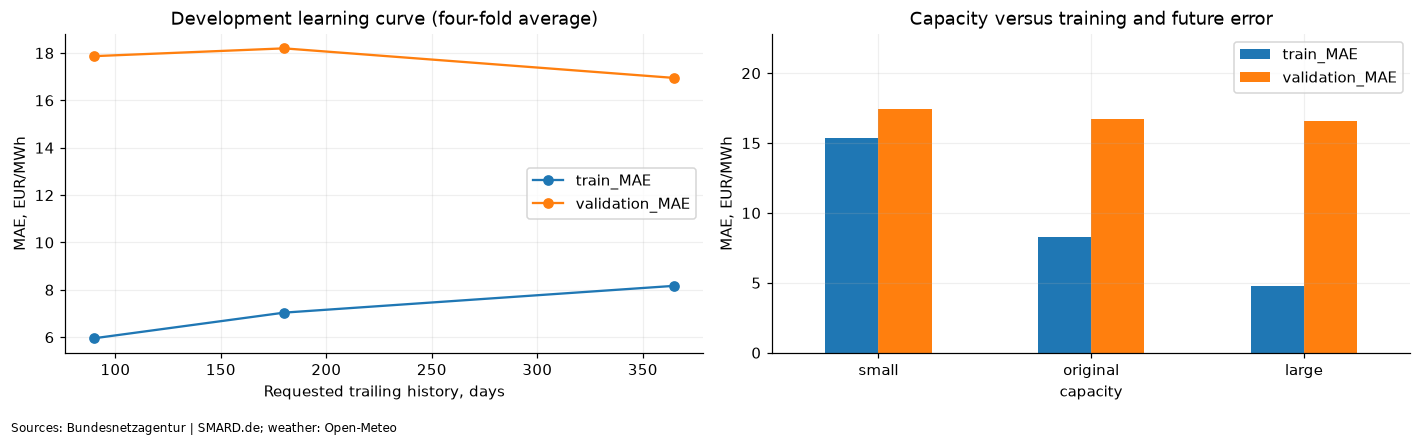

,fold,history_days,n_train,train_MAE,validation_MAE
0,1,90,2161,5.98,24.31
1,1,180,4321,6.48,25.56
2,1,365,5135,6.73,25.64
3,2,90,2160,7.13,15.66
4,2,180,4321,7.81,16.08
5,2,365,7343,8.53,14.00
6,3,90,2159,4.76,16.97
7,3,180,4319,7.36,17.79
8,3,365,8760,8.61,16.13
9,4,90,2160,5.95,14.52


,train_MAE,validation_MAE
capacity,,
large,4.77,16.57
original,8.30,16.72
small,15.36,17.40


In [37]:
curve_rows = []
for fold in folds:
    for history in [90, 180, 365]:
        train = development.loc[(development.index >= (fold['start']-pd.DateOffset(days=history)).tz_convert('UTC')) &
                                (development.index < fold['start'].tz_convert('UTC'))]
        valid = development.loc[(development.index >= fold['start'].tz_convert('UTC')) &
                                (development.index < fold['stop'].tz_convert('UTC'))]
        model = lgb_factory(best_params)().fit(train[feature_columns], train[TARGET])
        curve_rows.append({'fold': fold['fold'], 'history_days': history, 'n_train': len(train),
                           'train_MAE': regression_metrics(train[TARGET], model.predict(train[feature_columns]))['MAE'],
                           'validation_MAE': regression_metrics(valid[TARGET], model.predict(valid[feature_columns]))['MAE']})
learning_curve = pd.DataFrame(curve_rows)
capacity_rows = []
for fold in folds:
    train = development.loc[development.index < fold['start'].tz_convert('UTC')]
    valid = development.loc[(development.index >= fold['start'].tz_convert('UTC')) & (development.index < fold['stop'].tz_convert('UTC'))]
    for label, changes in [('small', {'num_leaves':7, 'n_estimators':100, 'min_child_samples':200}),
                           ('original', {}), ('large', {'num_leaves':63, 'n_estimators':500, 'min_child_samples':20})]:
        model = lgb_factory(dict(model_params, **changes))().fit(train[feature_columns], train[TARGET])
        capacity_rows.append({'fold': fold['fold'], 'capacity': label,
                             'train_MAE': regression_metrics(train[TARGET], model.predict(train[feature_columns]))['MAE'],
                             'validation_MAE': regression_metrics(valid[TARGET], model.predict(valid[feature_columns]))['MAE']})
capacity = pd.DataFrame(capacity_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
learning_curve.groupby('history_days')[['train_MAE','validation_MAE']].mean().plot(marker='o', ax=axes[0])
axes[0].set(title='Development learning curve (four-fold average)', xlabel='Requested trailing history, days', ylabel='MAE, EUR/MWh')
capacity.groupby('capacity')[['train_MAE','validation_MAE']].mean().reindex(['small','original','large']).plot.bar(ax=axes[1], rot=0)
axes[1].set(title='Capacity versus training and future error', ylabel='MAE, EUR/MWh')
axes[1].set_ylim(0, capacity[['train_MAE','validation_MAE']].mean().max()*1.35)
axes[1].set_ylim(0, capacity[['train_MAE','validation_MAE']].mean().max()*1.35)
finish(fig, '13_learning_and_capacity')
display(learning_curve.round(2)); display(capacity.groupby('capacity')[['train_MAE','validation_MAE']].mean().round(2))
learning_curve.to_csv(EXT / 'learning_curve.csv', index=False)
capacity.to_csv(EXT / 'capacity_diagnostics.csv', index=False)

## 18. Retrospective test comparison after freezing development choices

We now evaluate the development-selected point model, the best weekly LightGBM and its
daily variant, plus linear and neural competitors. All predict the **same 8,760 hours**.
The original results are included unchanged for context. This test year was already viewed
before this extension, so the table is not an untouched confirmation of the revised design.

Training metrics average fit-level errors with training-row weights; overlapping rolling
windows count observations repeatedly. They describe fit behavior, not independent accuracy.
No percentage accuracy or MAPE is reported because prices may be zero or negative.

Test: LightGBM trial 00 | MAE 18.251 | elapsed 71.4 seconds


Test: Selected LightGBM daily | MAE 17.585 | elapsed 489.0 seconds


Test: Ridge | MAE 20.761 | elapsed 6.8 seconds


Test: Pooled Lasso | MAE 20.888 | elapsed 90.4 seconds


Test: Small MLP | MAE 21.81 | elapsed 164.8 seconds


,MAE,RMSE,bias,median_AE,p95_AE,within_20_pct,n_hours,train_MAE,train_RMSE,n_fits,fits_with_warnings,MAE_improvement_vs_weekly_pct
model,,,,,,,,,,,,
Selected LightGBM daily,17.585,30.321,-2.551,11.340,50.864,71.587,8760,10.112,23.588,365.0,0.0,52.136
LightGBM trial 00,18.251,30.883,-2.872,12.065,52.464,70.126,8760,10.123,23.649,53.0,0.0,50.323
LightGBM market + forecast weather,19.193,32.071,-3.200,13.026,53.883,67.317,8760,NaN,NaN,NaN,NaN,47.761
Ridge,20.761,31.487,-2.891,15.579,53.279,60.856,8760,18.155,28.890,53.0,0.0,43.492
Pooled Lasso,20.888,31.645,-3.189,15.748,53.634,60.126,8760,18.135,28.939,53.0,0.0,43.147
Small MLP,21.810,33.777,1.081,15.948,58.444,60.126,8760,12.978,18.104,53.0,23.0,40.636
Previous-day naive,29.339,46.903,-0.161,16.690,99.821,55.548,8760,NaN,NaN,NaN,NaN,20.144
LightGBM market,29.962,44.827,-2.582,20.964,85.196,48.014,8760,NaN,NaN,NaN,NaN,18.448
Weekday-aware naive,31.532,49.706,0.764,17.820,102.590,53.037,8760,NaN,NaN,NaN,NaN,14.176


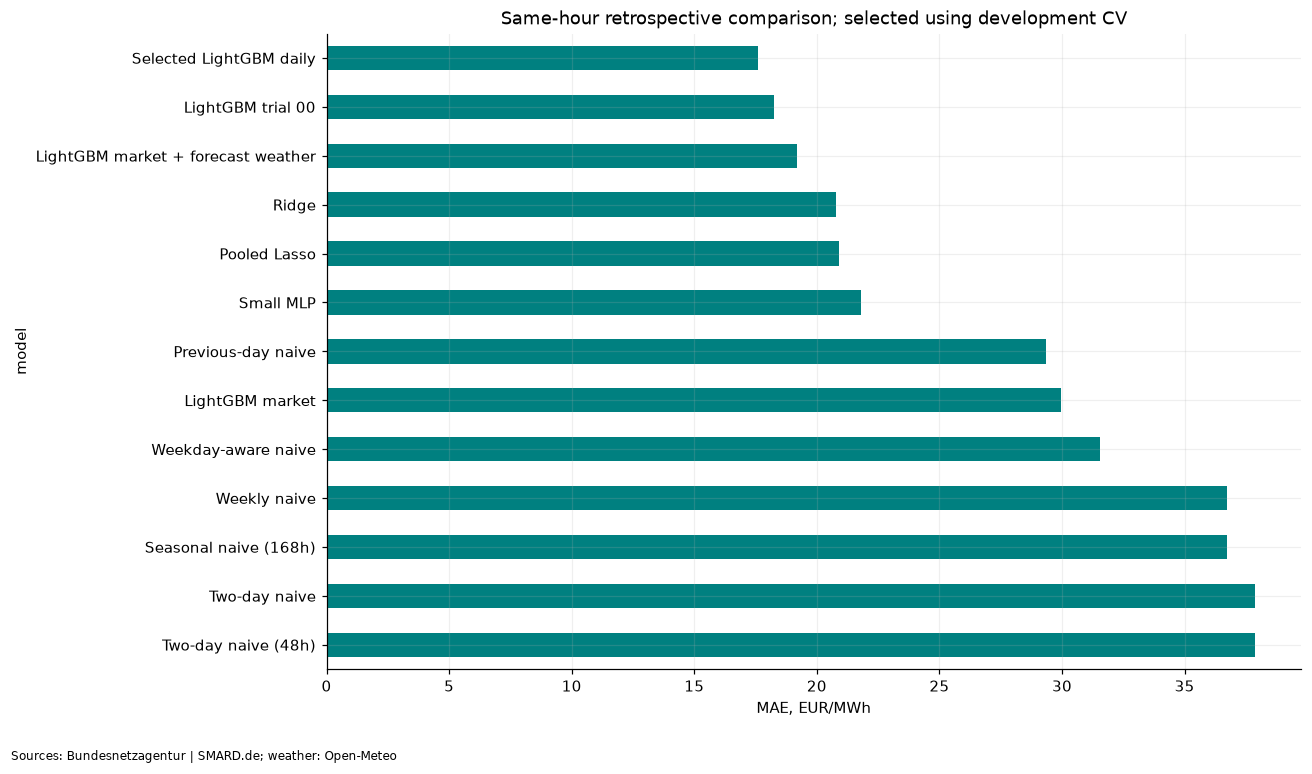

In [38]:
test_extended = predictions.copy()
for name, values in naive_predictions(enhanced.loc[expected_test]).items():
    test_extended[name] = values
test_logs = {}
test_names = list(dict.fromkeys([best_trial, daily_name, 'Ridge', 'Pooled Lasso', 'Small MLP', selected_name]))
for name in test_names:
    if name == 'Original 56-feature LightGBM':
        # Refit to record fit-level errors, even though original predictions already exist.
        pass
    started = time.perf_counter()
    pred, log = audit_backtest(enhanced, begin=TEST_BEGIN, stop=TEST_STOP, **family_specs[name])
    test_extended[name] = pred.prediction
    test_logs[name] = log
    print('Test:', name, '| MAE', round(regression_metrics(pred.actual, pred.prediction)['MAE'],3),
          '| elapsed', round(time.perf_counter()-started,1), 'seconds', flush=True)
test_rows = []
for name in test_extended.columns.drop('actual'):
    row = {'model': name, **regression_metrics(test_extended.actual, test_extended[name])}
    if name in test_logs:
        log = test_logs[name]
        row.update(train_MAE=np.average(log.train_MAE, weights=log.n_train),
                   train_RMSE=np.sqrt(np.average(log.train_RMSE**2, weights=log.n_train)), n_fits=len(log),
                   fits_with_warnings=int(log.warnings.ne('').sum()))
    test_rows.append(row)
extended_scores = pd.DataFrame(test_rows).set_index('model')
extended_scores['MAE_improvement_vs_weekly_pct'] = 100*(1-extended_scores.MAE/extended_scores.loc['Weekly naive','MAE'])
display(extended_scores.sort_values('MAE').round(3))
extended_scores.to_csv(EXT / 'model_results.csv')
test_extended.to_parquet(EXT / 'test_predictions.parquet')
pd.concat([log.assign(model=name) for name,log in test_logs.items()]).to_csv(EXT / 'test_fit_diagnostics.csv')
fig, ax = plt.subplots(figsize=(12, 7))
extended_scores.MAE.sort_values(ascending=False).plot.barh(ax=ax, color='teal')
ax.set(title='Same-hour retrospective comparison; selected using development CV', xlabel='MAE, EUR/MWh')
finish(fig, '14_extended_comparison')

## 19. Robustness: paired weekly-block bootstrap and error concentration

Hours from the same weather/market episode are dependent. We therefore resample contiguous
seven-day blocks of **daily paired loss differences**, rather than individual hours, to
estimate uncertainty in mean MAE improvement. Positive improvement means the selected model
has lower MAE. The 95% bootstrap interval is approximate and conditional on this historical
year; it does not correct model-selection bias or establish future profitability.

Hourly/monthly bias and MAE identify where failures concentrate. Actual-price regimes are
diagnostic labels available after the event, never forecast-time inputs. Extreme prices are
retained; large error does not itself make a value a data error.

,MAE_improvement,lower_95,upper_95
reference,,,
Weekly naive,19.155,16.297,22.394
Previous-day naive,11.754,9.999,13.504
LightGBM market + forecast weather,1.608,1.039,2.201


,hours,MAE,median_AE,p95_AE,bias
hour,,,,,
0,365,10.78,7.35,33.42,-0.73
1,365,10.96,7.68,36.44,-0.40
2,365,11.36,8.23,33.90,-0.62
3,365,11.24,8.16,32.61,-0.34
4,365,11.68,8.71,34.13,-0.36
5,365,11.91,8.65,36.03,-0.63
6,365,14.34,9.74,45.92,-1.77
7,365,18.70,12.84,59.90,-4.90
8,365,20.18,15.26,53.26,-3.64


,hours,MAE,median_AE,p95_AE,bias
month,,,,,
2025-09,144,19.46,11.13,45.81,-18.23
2025-10,745,13.26,8.02,41.70,-3.58
2025-11,720,15.80,9.90,45.78,0.44
2025-12,744,11.94,9.75,29.37,5.96
2026-01,744,15.23,9.72,44.42,-2.26
2026-02,672,11.27,9.18,28.34,5.78
2026-03,743,19.35,15.24,49.09,-5.76
2026-04,720,20.88,11.10,65.66,6.33
2026-05,744,16.64,10.35,45.32,-4.65


,hours,MAE,median_AE,p95_AE,bias
weekday,,,,,
Friday,1248,16.12,11.31,43.64,-2.05
Monday,1248,21.88,15.20,62.65,-7.82
Saturday,1248,14.92,9.33,54.68,4.12
Sunday,1248,15.01,9.46,45.79,-1.66
Thursday,1272,18.04,12.20,48.92,-1.50
Tuesday,1248,19.47,11.58,56.45,-6.70
Wednesday,1248,17.64,12.40,44.08,-2.26


,hours,MAE,median_AE,p95_AE,bias
price_regime,,,,,
negative,503,25.34,12.45,77.35,19.74
0 to <100,3552,15.73,10.85,47.43,5.13
100 to <200,4369,14.06,10.79,39.27,-6.14
>=200,336,71.38,50.79,216.85,-70.47


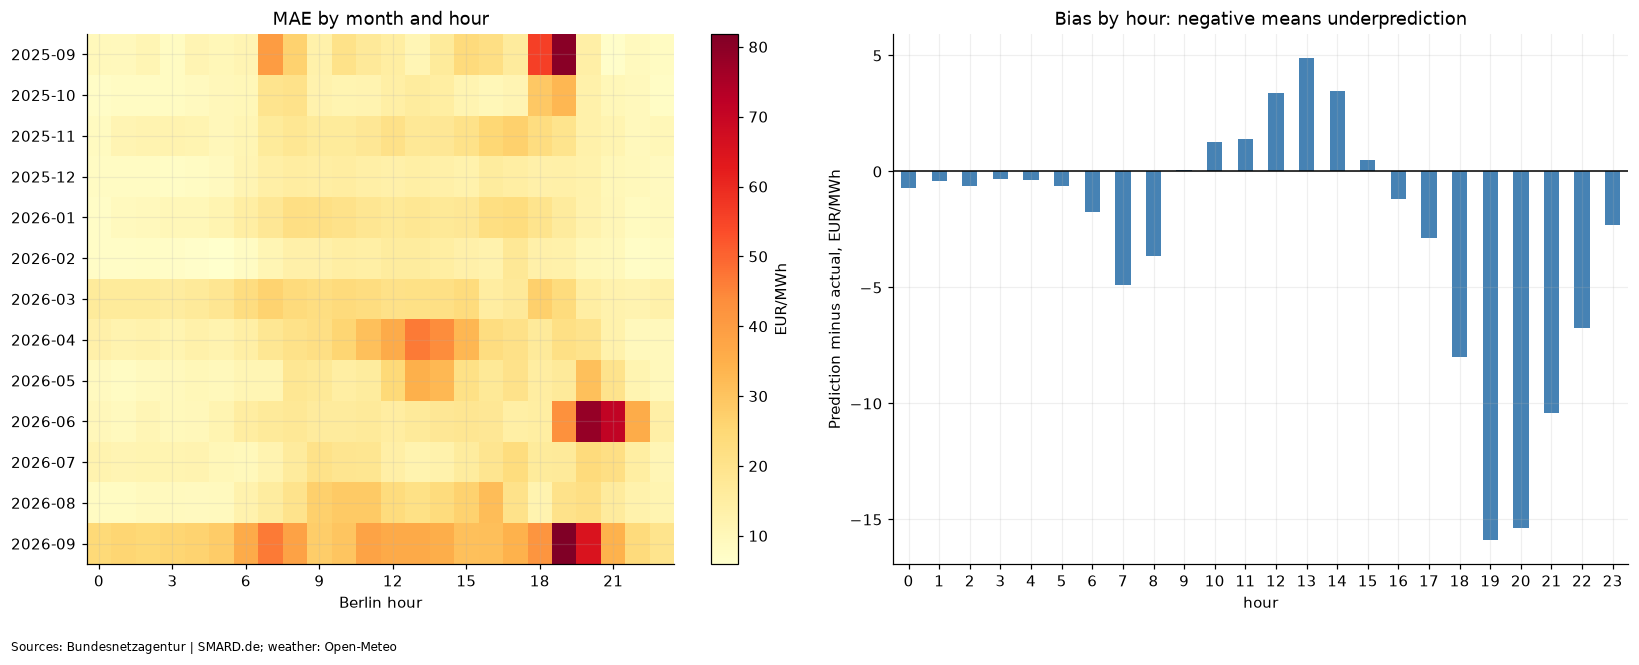

,delivery_time_berlin,actual,prediction,error
2026-05-01 11:00:00+00:00,2026-05-01 13:00:00+02:00,-499.00,-34.99,464.01
2026-09-14 17:00:00+00:00,2026-09-14 19:00:00+02:00,697.31,239.68,-457.63
2026-05-01 12:00:00+00:00,2026-05-01 14:00:00+02:00,-474.97,-33.86,441.11
2026-06-24 18:00:00+00:00,2026-06-24 20:00:00+02:00,665.82,230.72,-435.10
2026-06-24 19:00:00+00:00,2026-06-24 21:00:00+02:00,660.16,232.66,-427.50
2026-04-26 11:00:00+00:00,2026-04-26 13:00:00+02:00,-413.77,-27.81,385.96
2026-04-26 12:00:00+00:00,2026-04-26 14:00:00+02:00,-413.25,-28.33,384.92
2026-09-22 17:00:00+00:00,2026-09-22 19:00:00+02:00,596.38,233.47,-362.91
2026-06-23 18:00:00+00:00,2026-06-23 20:00:00+02:00,545.51,213.46,-332.05
2026-06-30 18:00:00+00:00,2026-06-30 20:00:00+02:00,504.77,178.90,-325.87


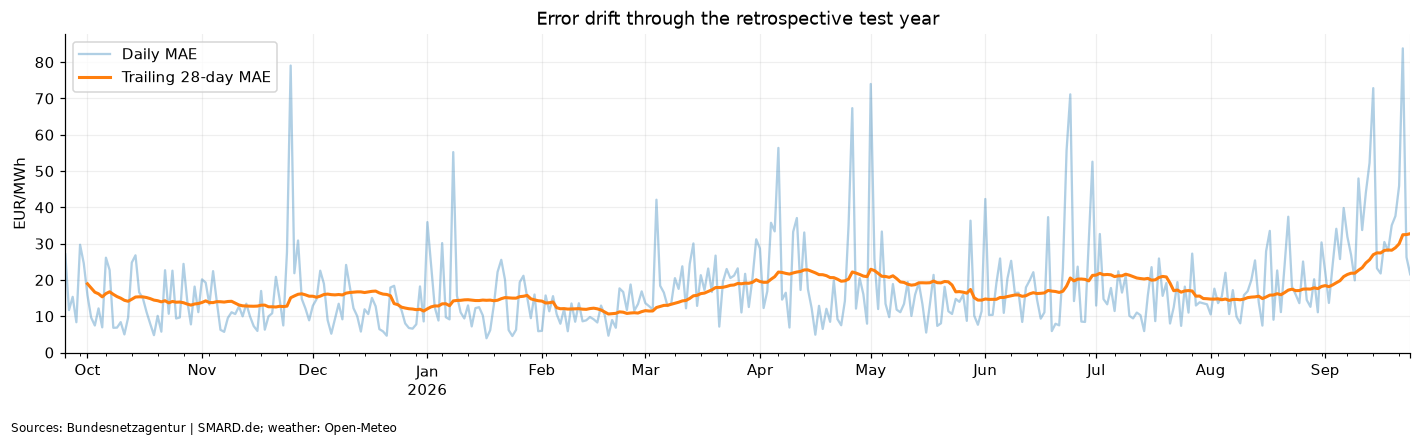

In [39]:
def paired_block_interval(actual, challenger, reference, samples=1000, block_days=7):
    d = pd.DataFrame({'improvement': (reference-actual).abs()-(challenger-actual).abs()}, index=actual.index)
    daily = d.groupby(d.index.tz_convert(TZ).normalize()).improvement.agg(['sum','count'])
    rng = np.random.default_rng(SEED)
    estimates = []
    for _ in range(samples):
        starts = rng.integers(0, len(daily), size=int(np.ceil(len(daily)/block_days)))
        indices = np.concatenate([(s+np.arange(block_days)) % len(daily) for s in starts])[:len(daily)]
        draw = daily.iloc[indices]
        estimates.append(draw['sum'].sum()/draw['count'].sum())
    return {'MAE_improvement': d.improvement.mean(), 'lower_95': np.quantile(estimates,.025),
            'upper_95': np.quantile(estimates,.975)}

robustness = pd.DataFrame([
    {'reference': reference, **paired_block_interval(test_extended.actual, test_extended[selected_name], test_extended[reference])}
    for reference in ['Weekly naive', 'Previous-day naive', 'LightGBM market + forecast weather']
]).set_index('reference')
display(robustness.round(3)); robustness.to_csv(EXT / 'paired_bootstrap.csv')
diagnostic = pd.DataFrame({'actual': test_extended.actual, 'prediction': test_extended[selected_name]})
diagnostic['error'] = diagnostic.prediction-diagnostic.actual
diagnostic['absolute_error'] = diagnostic.error.abs()
local = diagnostic.index.tz_convert(TZ)
diagnostic['hour'], diagnostic['month'] = local.hour, local.strftime('%Y-%m')
diagnostic['weekday'] = local.day_name()
diagnostic['price_regime'] = pd.cut(diagnostic.actual, [-np.inf,0,100,200,np.inf], right=False,
                                   labels=['negative','0 to <100','100 to <200','>=200'])
def error_slice(column):
    return diagnostic.groupby(column, observed=True).agg(hours=('error','size'), MAE=('absolute_error','mean'),
        median_AE=('absolute_error','median'), p95_AE=('absolute_error',lambda s:s.quantile(.95)), bias=('error','mean'))
for group in ['hour','month','weekday','price_regime']:
    table = error_slice(group)
    display(table.round(2)); table.to_csv(EXT / f'errors_by_{group}.csv')
heat = diagnostic.groupby(['month','hour']).absolute_error.mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
im = axes[0].imshow(heat, aspect='auto', cmap='YlOrRd')
axes[0].set(yticks=range(len(heat)), yticklabels=heat.index, xticks=range(0,24,3), xlabel='Berlin hour', title='MAE by month and hour')
fig.colorbar(im, ax=axes[0], label='EUR/MWh')
error_slice('hour').bias.plot.bar(ax=axes[1], color='steelblue', rot=0)
axes[1].axhline(0,color='black',lw=1)
axes[1].set(title='Bias by hour: negative means underprediction', ylabel='Prediction minus actual, EUR/MWh')
finish(fig, '15_error_heatmap_and_bias')
worst = diagnostic.nlargest(20,'absolute_error').copy()
worst['delivery_time_berlin'] = worst.index.tz_convert(TZ)
display(worst[['delivery_time_berlin','actual','prediction','error']].assign(actual=worst.actual.round(2), prediction=worst.prediction.round(2), error=worst.error.round(2)))
worst.to_csv(EXT / 'largest_errors.csv')
daily_mae = diagnostic.absolute_error.groupby(local.normalize()).mean()
fig, ax = plt.subplots(figsize=(13,4))
daily_mae.plot(ax=ax, alpha=.35, label='Daily MAE')
daily_mae.rolling(28,min_periods=7).mean().plot(ax=ax, label='Trailing 28-day MAE', lw=2)
ax.set(title='Error drift through the retrospective test year', ylabel='EUR/MWh'); ax.legend()
finish(fig, '16_error_drift')

## 20. Prediction intervals: quantile models and measured coverage

Separate LightGBM models estimate the 10th and 90th conditional price quantiles, giving a
**nominal 80% interval**. They use the development-selected LightGBM structure/window and
weekly retraining. They are separate from the selected point predictor. Quantile crossing
is counted and repaired by sorting the two bounds at each hour.

Report empirical coverage, mean width, interval score (penalizing misses and excessive
width), and pinball loss. An 80% label is a target, not a guarantee. Coverage by hour and
price regime reveals conditional weaknesses; we do not recalibrate using test outcomes.

Quantile complete: 0.1


Quantile complete: 0.9


,value
nominal_coverage_pct,80.000
empirical_coverage_pct,61.975
mean_width,42.351
mean_interval_score,98.450
pinball_q10,4.473
pinball_q90,5.373
crossing_pct,0.091


,hours,coverage,width
price_regime,,,
negative,503,0.644,53.996
0 to <100,3552,0.622,37.984
100 to <200,4369,0.632,39.952
>=200,336,0.402,102.285


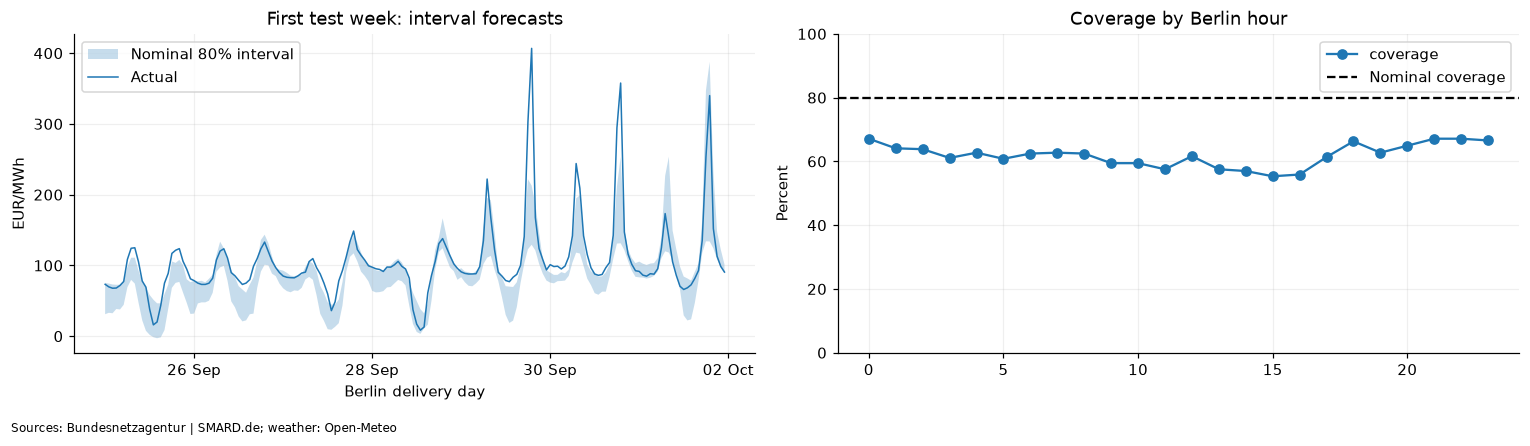

In [40]:
intervals = pd.DataFrame({'actual': test_extended.actual}, index=expected_test)
for q in [.1,.9]:
    params = dict(best_params, objective='quantile', alpha=q)
    pred, _ = audit_backtest(enhanced, lgb_factory(params), TEST_BEGIN, TEST_STOP,
                            window_days=best_spec['window_days'], retrain_days=7)
    intervals[f'q{int(q*100)}'] = pred.prediction
    print('Quantile complete:', q, flush=True)
crossing_rate = float((intervals.q10 > intervals.q90).mean())
intervals['lower'] = intervals[['q10','q90']].min(axis=1)
intervals['upper'] = intervals[['q10','q90']].max(axis=1)
intervals['covered'] = intervals.actual.between(intervals.lower,intervals.upper)
intervals['width'] = intervals.upper-intervals.lower
intervals['interval_score'] = intervals.width + 10*(intervals.lower-intervals.actual).clip(lower=0) + 10*(intervals.actual-intervals.upper).clip(lower=0)
interval_summary = pd.Series({'nominal_coverage_pct':80., 'empirical_coverage_pct':100*intervals.covered.mean(),
    'mean_width':intervals.width.mean(), 'mean_interval_score':intervals.interval_score.mean(),
    'pinball_q10':mean_pinball_loss(intervals.actual,intervals.q10,alpha=.1),
    'pinball_q90':mean_pinball_loss(intervals.actual,intervals.q90,alpha=.9), 'crossing_pct':100*crossing_rate})
display(interval_summary.round(3).to_frame('value'))
interval_by_hour = intervals.groupby(intervals.index.tz_convert(TZ).hour).agg(hours=('covered','size'),coverage=('covered','mean'),width=('width','mean'))
interval_by_regime = intervals.groupby(diagnostic.price_regime,observed=True).agg(hours=('covered','size'),coverage=('covered','mean'),width=('width','mean'))
display(interval_by_regime.round(3))
fig, axes = plt.subplots(1,2,figsize=(14,4))
first = intervals.iloc[:168].tz_convert(TZ)
axes[0].fill_between(first.index,first.lower,first.upper,alpha=.25,label='Nominal 80% interval')
axes[0].plot(first.index,first.actual,lw=1,label='Actual'); axes[0].legend()
axes[0].set(title='First test week: interval forecasts',ylabel='EUR/MWh',xlabel='Berlin delivery day')
import matplotlib.dates as mdates

axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=2,tz=TZ))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b',tz=TZ))
interval_by_hour.coverage.mul(100).plot(ax=axes[1],marker='o')
axes[1].axhline(80,color='black',ls='--',label='Nominal coverage'); axes[1].legend()
axes[1].set(title='Coverage by Berlin hour',ylabel='Percent',ylim=(0,100))
finish(fig,'17_prediction_intervals')
intervals.to_parquet(EXT / 'interval_predictions.parquet')
interval_summary.to_csv(EXT / 'interval_summary.csv')
interval_by_hour.to_csv(EXT / 'interval_coverage_by_hour.csv')
interval_by_regime.to_csv(EXT / 'interval_coverage_by_regime.csv')

## 21. Additional drivers: availability and integration contract

Not downloaded does not mean unavailable. ENTSO-E publishes forecast load, wind/solar
generation, generation unavailability and transmission data. Fuel/carbon histories may
require a particular product or access arrangement. We have not invented these columns
or silently treated tomorrow's actual generation/flows as forecasts.

The first useful additions are forecast load and renewable generation, followed by
outages/capacity and suitable fuel/carbon signals. More weather sites or capacity-weighted
weather require real historical location/capacity data; the five current points cannot
honestly stand in for such a dataset. These source-dependent additions remain pending.

The helper below accepts forecast revisions in long form with `valid_time`, `available_at`,
`feature` and `value`. It selects the most recent version **available by the issue cutoff**.
For a fuel settlement, construct the feature with the intended carry-forward horizon and
its publication time before using this helper. Missing availability timestamps are rejected.
Adding real sources requires rerunning development selection and updating the live schema.

[ENTSO-E data catalogue](https://transparencyplatform.zendesk.com/hc/en-us/articles/17260622859412-Transparency-Platform-Help-page) ·
[EEX historical natural-gas products](https://webshop.eex-group.com/data-type/eex-natural-gas-file-cloud-eod)

In [41]:
def select_available_covariates(revisions, delivery_index, issue_time):
    needed = {'valid_time','available_at','feature','value'}
    if not needed.issubset(revisions.columns):
        raise ValueError(f'Required columns: {sorted(needed)}')
    table = revisions.copy()
    for column in ['valid_time','available_at']:
        table[column] = pd.to_datetime(table[column],utc=True)
        if table[column].isna().any():
            raise ValueError(f'Missing {column}; availability must be explicit.')
    if table.duplicated(['valid_time','available_at','feature']).any():
        raise ValueError('Ambiguous revisions with identical availability timestamps.')
    eligible = table.loc[(table.available_at <= pd.Timestamp(issue_time).tz_convert('UTC')) &
                         table.valid_time.isin(delivery_index)]
    latest = eligible.sort_values('available_at').drop_duplicates(['valid_time','feature'],keep='last')
    return latest.pivot(index='valid_time',columns='feature',values='value').reindex(delivery_index)

driver_status = pd.DataFrame([
    ('Market history','Used','SMARD snapshot; historical revisions not reconstructed'),
    ('Five-site forecast weather','Used','48-hour lead; exact historical publication not known'),
    ('Load and renewable forecasts','Pending source integration','ENTSO-E/SMARD availability/version audit required'),
    ('Outages and cross-border capacity','Pending source integration','Use only announcements available before issue'),
    ('Fuel and carbon signals','Pending source integration','Choose accessible series and publication convention'),
    ('Capacity-weighted spatial weather','Pending source integration','Requires additional historical sites/capacity weights'),
],columns=['driver','status','requirement'])
display(driver_status)
driver_status.to_csv(EXT / 'driver_status.csv',index=False)

,driver,status,requirement
0,Market history,Used,SMARD snapshot; historical revisions not recon...
1,Five-site forecast weather,Used,48-hour lead; exact historical publication not...
2,Load and renewable forecasts,Pending source integration,ENTSO-E/SMARD availability/version audit required
3,Outages and cross-border capacity,Pending source integration,Use only announcements available before issue
4,Fuel and carbon signals,Pending source integration,Choose accessible series and publication conve...
5,Capacity-weighted spatial weather,Pending source integration,Requires additional historical sites/capacity ...


## 22. A notebook-contained forward-validation workflow

Historical validation cannot establish live operation. This section implements a live
collector, strict forecast cutoff, model persistence, immutable daily forecast records
and subsequent scoring. It requires no trading account and sends no messages.

**Historical Run All remains offline.** Set `RUN_LIVE_CYCLE = True` below and run this
section before **11:00 Europe/Berlin** to capture fresh SMARD and 48-hour-lead Open-Meteo
inputs and issue tomorrow's forecast. The cell refuses late runs. Run it on following days
to accumulate evidence; no OS scheduler is installed by this notebook. Scheduling can be
added when the modular application is updated. Keep the machine clock synchronized.

The collector preserves API responses with retrieval timestamps and hashes, saves feature
rows and the fitted model, and verifies non-cloud inputs. It refits on the selected daily
or weekly cadence using new eligible rows. It does not backfill missing features with
archive weather or a different forecast lead. If an API does not provide the required
future `_previous_day2` values, that cycle fails visibly rather than changing the experiment.
Retrieved-at means our system possessed the response then; it is not the provider's first
publication timestamp. A 30-hour generation-lag observation could still have revisions.

**A replay is executed below to test future-index construction with unknown targets.**
It uses old data and is explicitly labeled historical replay, never counted as live evidence.
Forward validation still needs future on-time forecasts and realized outcomes. A few weeks
can reveal operational faults; seasonal reliability requires longer observation.

In [42]:
import uuid

import requests

LIVE = EXT / 'live'
LIVE.mkdir(exist_ok=True)
LIVE_SERIES = {TARGET:(4169,'DE-LU'),'load_mwh':(410,'DE'),'residual_load_mwh':(4359,'DE'),
               'solar_mwh':(4068,'DE'),'wind_onshore_mwh':(4067,'DE'),'wind_offshore_mwh':(1225,'DE')}

def delivery_hours(delivery_day):
    day = pd.Timestamp(delivery_day)
    day = day.tz_localize(TZ) if day.tzinfo is None else day.tz_convert(TZ)
    day = day.normalize()
    return pd.date_range(day,day+pd.DateOffset(days=1),freq='h',inclusive='left').tz_convert('UTC')

def issue_cutoff(delivery_day):
    day = pd.Timestamp(delivery_day)
    day = day.tz_localize(TZ) if day.tzinfo is None else day.tz_convert(TZ)
    return (pd.Timestamp(day.date())-pd.DateOffset(days=1)+pd.Timedelta(hours=11)).tz_localize(TZ).tz_convert('UTC')

def prospective_features(market_history, weather_forecasts, delivery_day):
    future = delivery_hours(delivery_day)
    # Exclude any future price labels supplied in a download. Keep them elsewhere for later scoring.
    history = market_history.loc[market_history.index < future[0]].copy()
    index = pd.date_range(history.index.min(),future[-1],freq='h',tz='UTC')
    extended_market = history.reindex(index)
    features = enhanced_features(extended_market,weather_forecasts)
    requested = features.loc[future,feature_columns]
    required = [c for c in feature_columns if c not in cloud_columns]
    if requested[required].isna().any().any():
        bad = requested[required].columns[requested[required].isna().any()].tolist()
        raise ValueError(f'Missing required live features: {bad}')
    if not np.isfinite(requested.fillna(0).to_numpy()).all():
        raise ValueError('Non-finite live features.')
    assert features.loc[future,TARGET].isna().all()
    return requested, features

def save_json_exclusive(path, document):
    with Path(path).open('x',encoding='utf-8') as stream:
        json.dump(document,stream,indent=2,default=str)

def fetch_recorded_json(session,url,params,folder,label):
    response = session.get(url,params=params,timeout=45)
    received_at = pd.Timestamp.now(tz='UTC')
    response.raise_for_status()
    payload = response.json()
    save_json_exclusive(folder/f'{label}.json', {'url':response.url,'received_at_utc':received_at,
                                               'sha256':hashlib.sha256(response.content).hexdigest(),
                                               'response':payload})
    return payload

def collect_live_inputs(folder):
    now = pd.Timestamp.now(tz='UTC')
    tomorrow = now.tz_convert(TZ).normalize()+pd.DateOffset(days=1)
    # Refresh overlap to capture additions and revisions without overwriting raw research files.
    market_base = pd.read_parquet(LIVE/'market_latest.parquet') if (LIVE/'market_latest.parquet').exists() else market.copy()
    weather_base = pd.read_parquet(LIVE/'weather_latest.parquet') if (LIVE/'weather_latest.parquet').exists() else forecast.copy()
    start = min(market_base.index.max(),weather_base.index.max())-pd.Timedelta(days=7)
    series = {}
    with requests.Session() as session:
        for name,(fid,region) in LIVE_SERIES.items():
            base = f'https://www.smard.de/app/chart_data/{fid}/{region}'
            index = fetch_recorded_json(session,f'{base}/index_hour.json',None,folder,f'{name}_index')['timestamps']
            rows = []
            for stamp in index:
                if int(start.timestamp()*1000)-7*86400000 <= stamp <= int(now.timestamp()*1000):
                    rows.extend(fetch_recorded_json(session,f'{base}/{fid}_{region}_hour_{stamp}.json',None,
                                                    folder,f'{name}_{stamp}')['series'])
            df = pd.DataFrame(rows,columns=['timestamp','value'])
            if df.empty:
                raise ValueError(f'No refreshed market rows for {name}')
            df['timestamp'] = pd.to_datetime(df.timestamp,unit='ms',utc=True)
            series[name] = df.drop_duplicates('timestamp').set_index('timestamp').value.sort_index()
        recent_market = pd.DataFrame(series)
        weather_pieces = []
        for location,(lat,lon) in forecast_meta['locations'].items():
            fields = [f'{v}_previous_day2' for v in forecast_meta['variables']]
            params = {'latitude':lat,'longitude':lon,'hourly':','.join(fields),'models':forecast_meta['model'],
                      'start_date':start.strftime('%Y-%m-%d'),'end_date':(tomorrow+pd.DateOffset(days=1)).strftime('%Y-%m-%d'),
                      'timezone':'UTC','temperature_unit':'celsius','wind_speed_unit':'kmh'}
            payload = fetch_recorded_json(session,forecast_meta['endpoint'],params,folder,f'weather_{location}')
            hourly = pd.DataFrame(payload['hourly'])
            hourly.index = pd.to_datetime(hourly.pop('time'),utc=True)
            hourly = hourly.rename(columns={f'{v}_previous_day2':f'{location}__{v}' for v in forecast_meta['variables']})
            weather_pieces.append(hourly)
    # Latest refresh replaces even null values in its overlap; old non-null revisions do not hide new missingness.
    recent_weather = pd.concat(weather_pieces,axis=1)
    merged_market = pd.concat([market_base.loc[~market_base.index.isin(recent_market.index)],recent_market]).sort_index()
    merged_weather = pd.concat([weather_base.loc[~weather_base.index.isin(recent_weather.index)],recent_weather]).sort_index()
    merged_market.to_parquet(LIVE/'market_latest.parquet')
    merged_weather.to_parquet(LIVE/'weather_latest.parquet')
    merged_market.to_parquet(folder/'market_snapshot.parquet')
    merged_weather.to_parquet(folder/'weather_snapshot.parquet')
    return merged_market,merged_weather

def score_live_ledger(actual_prices, as_of=None):
    as_of = pd.Timestamp.now(tz='UTC') if as_of is None else pd.Timestamp(as_of).tz_convert('UTC')
    daily_rows = []
    for record_path in sorted(LIVE.glob('forecast_*.json')):
        record = json.loads(record_path.read_text(encoding='utf-8'))
        if record['mode'] != 'live':
            continue
        prediction = pd.read_parquet(LIVE/record['prediction_file'])
        actual = actual_prices.reindex(prediction.index)
        # Score only completed delivery intervals. Record the outcome snapshot time separately.
        ready = actual.notna() & (prediction.index+pd.Timedelta(hours=1) <= as_of)
        row = {'delivery_day':record['delivery_day'],'issued_at_utc':record['issued_at_utc'],
               'on_time':pd.Timestamp(record['issued_at_utc']) < pd.Timestamp(record['cutoff_utc']),
               'expected_hours':len(prediction),'scored_hours':int(ready.sum()),'outcomes_as_of_utc':as_of}
        if ready.any():
            row.update(regression_metrics(actual.loc[ready],prediction.loc[ready,'prediction']))
            row['weekly_baseline_MAE'] = regression_metrics(actual.loc[ready],prediction.loc[ready,'weekly_baseline'])['MAE']
            row['previous_day_MAE'] = regression_metrics(actual.loc[ready],prediction.loc[ready,'previous_day_baseline'])['MAE']
        daily_rows.append(row)
    scores_live = pd.DataFrame(daily_rows)
    scores_live.to_csv(LIVE/'scores.csv',index=False)
    return scores_live

def run_live_cycle():
    started = pd.Timestamp.now(tz='UTC')
    day = started.tz_convert(TZ).normalize()+pd.DateOffset(days=1)
    cutoff = issue_cutoff(day)
    if started >= cutoff:
        raise RuntimeError('Past 11:00 Berlin cutoff: no live forecast was issued. Run tomorrow before 11:00.')
    day_key = day.strftime('%Y-%m-%d')
    record_file = LIVE/f'forecast_{day_key}.json'
    if record_file.exists():
        raise FileExistsError('An immutable forecast already exists for this delivery day.')
    folder = LIVE/f'capture_{started.strftime("%Y%m%dT%H%M%SZ")}_{uuid.uuid4().hex[:8]}'
    folder.mkdir()
    try:
        fresh_market,fresh_weather = collect_live_inputs(folder)
        X_future,training_features = prospective_features(fresh_market,fresh_weather,day)
        columns = selected_spec.get('columns',feature_columns)
        train = training_features.loc[(training_features.index < delivery_hours(day)[0]) &
                                      (training_features.index >= (day-pd.DateOffset(days=selected_spec['window_days'])).tz_convert('UTC'))]
        train = train.dropna(subset=required_columns)
        if train.empty:
            raise ValueError('No eligible live training rows.')
        config_payload = {'selected_name':selected_name,'columns':columns,'window_days':selected_spec['window_days'],
                          'retrain_days':selected_spec['retrain_days'],'best_params':best_params}
        config_hash = hashlib.sha256(json.dumps(config_payload,sort_keys=True).encode()).hexdigest()
        state_path = LIVE/'model_state.json'
        state = json.loads(state_path.read_text()) if state_path.exists() else None
        refit = state is None or state['config_hash'] != config_hash or (day.date()-pd.Timestamp(state['fit_day']).date()).days >= selected_spec['retrain_days']
        if refit:
            model = selected_spec['factory']().fit(train[columns],train[TARGET])
            model_file = f'model_{started.strftime("%Y%m%dT%H%M%SZ")}_{uuid.uuid4().hex[:8]}.joblib'
            joblib.dump(model,LIVE/model_file)
            state = {'fit_day':day_key,'model_file':model_file,'config_hash':config_hash,
                     'train_start':str(train.index.min()),'train_end':str(train.index.max()),'n_train':len(train)}
            state_path.write_text(json.dumps(state,indent=2),encoding='utf-8')
        else:
            model = joblib.load(LIVE/state['model_file'])
        issued = pd.Timestamp.now(tz='UTC')
        if issued >= cutoff:
            raise RuntimeError('Collection/training finished after cutoff; forecast withheld.')
        output = pd.DataFrame({'prediction':model.predict(X_future[columns]),
                               'weekly_baseline':X_future[f'{TARGET}_lag168h'],
                               'previous_day_baseline':X_future[f'{TARGET}_lag24h']},index=X_future.index)
        if not np.isfinite(output.to_numpy()).all():
            raise ValueError('Non-finite predictions; forecast withheld.')
        prediction_file = f'predictions_{day_key}.parquet'
        if (LIVE/prediction_file).exists():
            raise FileExistsError('Prediction artifact already exists; inspect the previous incomplete cycle.')
        X_future.to_parquet(folder/'forecast_features.parquet')
        output.to_parquet(LIVE/prediction_file)
        issued = pd.Timestamp.now(tz='UTC')
        if issued >= cutoff:
            raise RuntimeError('Persistence passed the cutoff; this artifact is not a valid live forecast.')
        save_json_exclusive(record_file, {'mode':'live','delivery_day':day_key,'issued_at_utc':issued,
            'cutoff_utc':cutoff,'prediction_file':prediction_file,
            'prediction_sha256':hashlib.sha256((LIVE/prediction_file).read_bytes()).hexdigest(),
            'capture_directory':str(folder.relative_to(LIVE)),'model_state':state,'configuration':config_payload,
            'weather_policy':forecast_meta['availability_note']})
        save_json_exclusive(folder/'status.json',{'status':'issued','issued_at_utc':issued})
        return output,score_live_ledger(fresh_market[TARGET])
    except Exception as exc:
        save_json_exclusive(folder/'failure.json',{'status':'failed','at_utc':pd.Timestamp.now(tz='UTC'),
                                                 'error_type':type(exc).__name__,'message':str(exc)})
        raise

In [43]:
# Executed historical replay: future target rows do not exist in the input history.
replay_day = pd.Timestamp(TEST_START,tz=TZ)
replay_hours = delivery_hours(replay_day)
replay_X,replay_train = prospective_features(market.loc[market.index < replay_hours[0]],forecast,replay_day)
replay_train = replay_train.loc[replay_train.index < replay_hours[0]].dropna(subset=required_columns)
replay_train = replay_train.loc[replay_train.index >= (replay_day-pd.DateOffset(days=selected_spec['window_days'])).tz_convert('UTC')]
replay_columns = selected_spec.get('columns',feature_columns)
replay_model = selected_spec['factory']().fit(replay_train[replay_columns],replay_train[TARGET])
replay_output = pd.DataFrame({'prediction':replay_model.predict(replay_X[replay_columns]),
                              'actual_for_later_scoring':market.loc[replay_hours,TARGET],
                              'mode':'historical_replay'},index=replay_hours)
assert np.allclose(replay_output.prediction,test_extended.loc[replay_hours,selected_name])
replay_output.to_parquet(EXT/'historical_replay.parquet')
joblib.dump({'model':replay_model,'columns':replay_columns,'trained_through':replay_train.index.max(),
             'mode':'historical_replay'},EXT/'replay_model.joblib')
display(replay_output.head())
print('Replay passed. This is not evidence of live forecasting performance.')

RUN_LIVE_CYCLE = False  # Set True and run before 11:00 Berlin; network access is required.
if RUN_LIVE_CYCLE:
    live_forecast,live_scores = run_live_cycle()
    display(live_forecast); display(live_scores)
else:
    now_local = pd.Timestamp.now(tz=TZ)
    print('Live mode disabled for the historical run. Current Berlin time:',now_local)
    print('Existing live forecast records:',len(list(LIVE.glob('forecast_*.json'))))

,prediction,actual_for_later_scoring,mode
2025-09-24 22:00:00+00:00,58.029409,73.30,historical_replay
2025-09-24 23:00:00+00:00,59.196223,69.69,historical_replay
2025-09-25 00:00:00+00:00,49.663502,67.81,historical_replay
2025-09-25 01:00:00+00:00,50.960110,68.09,historical_replay
2025-09-25 02:00:00+00:00,53.130277,71.69,historical_replay


Replay passed. This is not evidence of live forecasting performance.
Live mode disabled for the historical run. Current Berlin time: 2026-09-28 16:09:29.867014+02:00
Existing live forecast records: 0


## 23. Meaningful checks for the extended workflow

These checks verify chronology, equal evaluation coverage, feature causality, training-only
transforms, interval ordering, DST day lengths and late-revision rejection. They test code
and information flow; they cannot prove old publication timestamps or future accuracy.
The live network collector is not exercised by the offline run and needs an on-time live trial.

In [44]:
extension_checks = []
assert all(f['stop'] <= TEST_BEGIN.tz_convert(TZ) for f in folds)
assert (pd.to_datetime(cv_logs.train_end,utc=True) < pd.to_datetime(cv_logs.fit_day,utc=True)).all()
extension_checks.append(('Every CV fit precedes its forecast and all CV folds precede the test year','PASS'))
assert TARGET not in feature_columns and len(feature_columns) == 57
changed_market = market.copy()
changed_market.loc[changed_market.index >= TEST_BEGIN,TARGET] += 10000
before = enhanced_features(market,forecast).loc[:TEST_BEGIN,feature_columns]
after = enhanced_features(changed_market,forecast).loc[:TEST_BEGIN,feature_columns]
pd.testing.assert_frame_equal(before,after)
extension_checks.append(('Current/future target changes cannot alter current/past predictors','PASS'))
assert np.isfinite(test_extended.to_numpy()).all() and len(test_extended)==8760
for name in test_extended.columns.drop('actual'):
    assert np.isclose(regression_metrics(test_extended.actual,test_extended[name])['MAE'],extended_scores.loc[name,'MAE'])
extension_checks.append(('All compared models score identical 8760 hours with independently checked metrics','PASS'))
assert (intervals.lower <= intervals.upper).all() and intervals.covered.between(0,1).all()
extension_checks.append(('Interval bounds ordered and coverage computed from observed targets','PASS'))
assert len(delivery_hours('2026-03-29'))==23 and len(delivery_hours('2025-10-26'))==25
assert issue_cutoff('2026-03-29').tz_convert(TZ).hour==11
extension_checks.append(('Prospective forecast indices and cutoff honor DST','PASS'))
fake_time = pd.Timestamp('2025-01-02 12:00',tz='UTC')
revision_example = pd.DataFrame({'valid_time':[fake_time]*2,
    'available_at':[pd.Timestamp('2025-01-01 08:00',tz='UTC'),pd.Timestamp('2025-01-01 12:00',tz='UTC')],
    'feature':['wind_forecast']*2,'value':[10.,999.]})
selected_revision = select_available_covariates(revision_example,pd.DatetimeIndex([fake_time]),pd.Timestamp('2025-01-01 10:00',tz='UTC'))
assert selected_revision.iloc[0,0]==10.
extension_checks.append(('Late covariate revisions are excluded at the issue cutoff','PASS'))
# A fitted imputer must keep its training median when predicting an extreme validation value.
tiny_pipeline = ridge_factory().fit(pd.DataFrame({'x':[1.,np.nan,3.]}),[1.,2.,3.])
median_before = tiny_pipeline.named_steps['simpleimputer'].statistics_.copy()
tiny_pipeline.predict(pd.DataFrame({'x':[1e9,np.nan]}))
assert np.array_equal(median_before,tiny_pipeline.named_steps['simpleimputer'].statistics_)
extension_checks.append(('Prediction cannot refit training imputation statistics','PASS'))
assert replay_output['mode'].eq('historical_replay').all()
assert not (LIVE/f'forecast_{TEST_START}.json').exists()
extension_checks.append(('Historical replay matches test predictions and is not entered in live ledger','PASS'))
display(pd.DataFrame(extension_checks,columns=['check','result']))
pd.DataFrame(extension_checks,columns=['check','result']).to_csv(EXT/'validation_checks.csv',index=False)

,check,result
0,Every CV fit precedes its forecast and all CV ...,PASS
1,Current/future target changes cannot alter cur...,PASS
2,All compared models score identical 8760 hours...,PASS
3,Interval bounds ordered and coverage computed ...,PASS
4,Prospective forecast indices and cutoff honor DST,PASS
5,Late covariate revisions are excluded at the i...,PASS
6,Prediction cannot refit training imputation st...,PASS
7,Historical replay matches test predictions and...,PASS


## 24. Updated conclusions and remaining work

The following findings are generated from the completed experiments. A measured change
can be an improvement, no change or a regression. We keep genuine extreme outcomes in
every evaluation. We do not declare the model free of overfitting simply because it beats
a baseline, and we do not present nominal intervals as calibrated without checking coverage.

In [45]:
winner = extended_scores.loc[selected_name]
original = extended_scores.loc['LightGBM market + forecast weather']
daily_cv = cv_board.loc[daily_name,'CV_MAE']
weekly_cv = cv_board.loc[best_trial,'CV_MAE']
capacity_means = capacity.groupby('capacity')[['train_MAE','validation_MAE']].mean()
capacity_message = ('The larger tree model lowers training error but raises validation error: this capacity experiment shows an overfitting warning.'
    if capacity_means.loc['large','train_MAE'] < capacity_means.loc['original','train_MAE'] and capacity_means.loc['large','validation_MAE'] > capacity_means.loc['original','validation_MAE']
    else 'The capacity experiment does not show a simple monotonic overfitting pattern; inspect fold-level results and the train/validation gaps.')
largest_hours = error_slice('hour').MAE.nlargest(3)
display(Markdown(f"""
**Selected using development CV:** {selected_name}; CV MAE **{cv_board.loc[selected_name,'CV_MAE']:.2f} EUR/MWh**.
Its recorded rolling training MAE is **{winner['train_MAE']:.2f}** and retrospective test MAE/RMSE are
**{winner.MAE:.2f} / {winner.RMSE:.2f} EUR/MWh**. Training windows overlap; this is not a count of independent samples.
The original weather-model MAE was **{original.MAE:.2f}**; the revised selection changes it by
**{100*(1-winner.MAE/original.MAE):+.1f}% improvement** (negative means worse).

**Retraining:** selected LightGBM CV MAE is **{weekly_cv:.2f} weekly** versus **{daily_cv:.2f} daily**.
Daily fitting is {'better' if daily_cv < weekly_cv else 'not better'} on these development folds.
Use the saved fold variation and paired comparisons rather than assuming that more fits are superior.

**Fit diagnosis:** {capacity_message} This does not establish an absence of overfitting or underfitting
in the selected model; changing regimes and missing price drivers remain alternative explanations.

**Uncertainty:** nominal 80% intervals cover **{100*intervals.covered.mean():.1f}%** of test hours;
their mean width is **{intervals.width.mean():.2f} EUR/MWh**. Coverage must be evaluated by regime too.
**Error concentration:** the largest average hourly errors occur at Berlin hours
**{', '.join(str(h)+':00' for h in largest_hours.index)}**. These are averages, not a claim that every such hour fails.

**Operational status:** the future-index replay passed. Live collection, timestamped forecast recording,
model persistence and later scoring are implemented in this notebook. No scheduler is installed and
**no new live-validation results are claimed by this offline run**. External drivers remain pending
source integration; historical publication/revision assumptions remain explicit.

**Next observation needed:** collect on-time live forecasts under the frozen policy, compare against
both weekly and previous-day baselines, and monitor late/missing inputs as well as MAE and extreme errors.
The already-inspected test year cannot become an untouched holdout again.
"""))
selection_record = {'created_at_utc':pd.Timestamp.now(tz='UTC').isoformat(),'selected_name':selected_name,
    'best_lgbm_trial':best_trial,'best_lgbm_params':best_params,'selected_window_days':selected_spec['window_days'],
    'selected_retrain_days':selected_spec['retrain_days'],'selected_features':selected_spec.get('columns',feature_columns),
    'cv_folds':[{k:str(v) for k,v in f.items()} for f in folds], 'input_manifest':manifest,
    'test_status':'Previously inspected retrospective benchmark; not a fresh holdout',
    'live_status':'Implemented; live collection disabled in reproducible historical execution',
    'external_drivers':'Not integrated; as-of selection helper implemented',
    'versions':{p:importlib.metadata.version(p) for p in ['pandas','numpy','scikit-learn','lightgbm']}}
(EXT/'selection_record.json').write_text(json.dumps(selection_record,indent=2),encoding='utf-8')
print('Saved extension artifacts to:',EXT)


**Selected using development CV:** Selected LightGBM daily; CV MAE **15.25 EUR/MWh**.
Its recorded rolling training MAE is **10.11** and retrospective test MAE/RMSE are
**17.58 / 30.32 EUR/MWh**. Training windows overlap; this is not a count of independent samples.
The original weather-model MAE was **19.19**; the revised selection changes it by
**+8.4% improvement** (negative means worse).

**Retraining:** selected LightGBM CV MAE is **15.84 weekly** versus **15.25 daily**.
Daily fitting is better on these development folds.
Use the saved fold variation and paired comparisons rather than assuming that more fits are superior.

**Fit diagnosis:** The capacity experiment does not show a simple monotonic overfitting pattern; inspect fold-level results and the train/validation gaps. This does not establish an absence of overfitting or underfitting
in the selected model; changing regimes and missing price drivers remain alternative explanations.

**Uncertainty:** nominal 80% intervals cover **62.0%** of test hours;
their mean width is **42.35 EUR/MWh**. Coverage must be evaluated by regime too.
**Error concentration:** the largest average hourly errors occur at Berlin hours
**19:00, 20:00, 13:00**. These are averages, not a claim that every such hour fails.

**Operational status:** the future-index replay passed. Live collection, timestamped forecast recording,
model persistence and later scoring are implemented in this notebook. No scheduler is installed and
**no new live-validation results are claimed by this offline run**. External drivers remain pending
source integration; historical publication/revision assumptions remain explicit.

**Next observation needed:** collect on-time live forecasts under the frozen policy, compare against
both weekly and previous-day baselines, and monitor late/missing inputs as well as MAE and extreme errors.
The already-inspected test year cannot become an untouched holdout again.


Saved extension artifacts to: C:\Users\rosha\OneDrive\Documents\de-power-price-forecast\data\processed\presentation\improvements


## 25. Development baselines alongside the selected model

This independent audit applies all four baseline rules to the exact development folds used
for model selection. It confirms that the learned-model comparison is meaningful relative to
simple rules too. The selected learned model remains the model chosen in section 16; this
appendix does not change its configuration using test results. The code can execute separately
after the preceding sections have saved their artifacts.


In [5]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

audit_root = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/raw').is_dir())
audit_out = audit_root/'data/processed/presentation/improvements'
audit_policy = json.loads((audit_out/'selection_record.json').read_text(encoding='utf-8'))
audit_market_path = audit_root/'data/raw/smard_sample.parquet'
if not audit_market_path.exists():
    audit_market_path = audit_root/'data/raw/smard.parquet'
audit_y = pd.read_parquet(audit_market_path).price_eur_mwh.asfreq('h')
audit_frame = pd.DataFrame({'actual':audit_y,'Weekly naive':audit_y.shift(168),
                           'Two-day naive':audit_y.shift(48),'Previous-day naive':audit_y.shift(24)})
audit_frame['Weekday-aware naive'] = np.where(audit_frame.index.tz_convert('Europe/Berlin').dayofweek.isin([1,2,3,4]),
                                             audit_frame['Previous-day naive'],audit_frame['Weekly naive'])
audit_rows = []
for fold in audit_policy['cv_folds']:
    begin,stop = pd.Timestamp(fold['start']),pd.Timestamp(fold['stop'])
    hours = pd.date_range(begin,stop,freq='h',inclusive='left').tz_convert('UTC')
    sample = audit_frame.loc[hours]
    assert sample.notna().all().all()
    for name in sample.columns.drop('actual'):
        error = sample[name]-sample.actual
        audit_rows.append({'model':name,'fold':int(fold['fold']),'MAE':error.abs().mean(),
                           'RMSE':np.sqrt((error**2).mean()),'n_hours':len(error)})
baseline_cv = pd.DataFrame(audit_rows)
baseline_cv.to_csv(audit_out/'baseline_cv_results.csv',index=False)
baseline_board = baseline_cv.groupby('model').agg(CV_MAE=('MAE','mean'),sd_fold_MAE=('MAE','std'))
learned_board = pd.read_csv(audit_out/'cv_leaderboard.csv',index_col='model')
selected = audit_policy['selected_name']
comparison = pd.concat([baseline_board,learned_board.loc[[selected],['CV_MAE','sd_fold_MAE']]])
display(comparison.sort_values('CV_MAE').round(3))
comparison.to_csv(audit_out/'cv_baseline_comparison.csv')
print('All four folds have equal duration here; the mean fold MAE equals pooled hourly MAE.')
selected_folds = pd.read_csv(audit_out/'cv_fold_results.csv')
selected_folds = selected_folds.loc[selected_folds.model.eq(selected),
    ['fold','train_MAE','MAE','RMSE','n_hours','n_fits','fits_with_warnings']]
print('Selected model: training and subsequent validation errors in each fold')
display(selected_folds.round(3))
print('Development-selected LightGBM configuration:',audit_policy['best_lgbm_trial'])
print('Starting configuration won the bounded search:',audit_policy['best_lgbm_trial']=='LightGBM trial 00')
display(pd.Series(audit_policy['best_lgbm_params']).to_frame('parameter_value'))
print('Selected point-model input count:',len(audit_policy['selected_features']),
      '| training window:',audit_policy['selected_window_days'],'days',
      '| refit interval:',audit_policy['selected_retrain_days'],'calendar days')

,CV_MAE,sd_fold_MAE
model,,
Selected LightGBM daily,15.249,4.239
Previous-day naive,24.669,7.121
Weekday-aware naive,25.502,7.162
Weekly naive,30.767,7.911
Two-day naive,31.600,9.611


All four folds have equal duration here; the mean fold MAE equals pooled hourly MAE.
Selected model: training and subsequent validation errors in each fold


,fold,train_MAE,MAE,RMSE,n_hours,n_fits,fits_with_warnings
44,1,7.280,21.180,49.808,672,28,0
45,2,8.551,13.128,16.604,672,28,0
46,3,8.762,15.210,24.352,672,28,0
47,4,9.274,11.477,18.247,672,28,0


Development-selected LightGBM configuration: LightGBM trial 00
Starting configuration won the bounded search: True


,parameter_value
n_estimators,250
learning_rate,0.05
num_leaves,31
min_child_samples,40
reg_lambda,1.0
objective,regression_l1
random_state,42
n_jobs,2
verbosity,-1


Selected point-model input count: 57 | training window: 730 days | refit interval: 1 calendar days
